## Table of Contents
- [1. Data Loading](#data-loading)
- [2. Cleaning](#cleaning)
- [3. EDA Univariate analysis](#EDA-Univariate-analysis)
- [4. EDA - Bivariate](#category-demand)
    - [4.1 medicine v/s demand](#medicine-v/s-demand)
    - [4.2 medicine v/s opening stock](#medicine-v/s-opening-stock)
    - [4.3 medicine v/s closing stock](#medicine-v/s-closing-stock)
    - [4.4 medicine v/s restock](#medicine-v/s-restock)
    - [4.5 medicine v/s demand fulfilled](#medicine-v/s-restock)
    - [4.6 medicine v/s stock out](#medicine-v/s-stock-out)
    - [4.7 medicine v/s lead time](#medicine-v/s-lead-time)
    - [4.8 medicine v/s ordering cost](#medicine-v/s-ordering-cost)


    

- [5. Ordering Cost Analysis](#ordering-cost)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

<a id="data-loading"></a>
## 1. Data Loading

In [2]:
data =pd.read_csv(r"C:\Users\HARSH\OneDrive\Desktop\pharmacy-inventory-optimisation\pharmacy_inventory_data_.csv")
data.head()

,Medicine_ID,Medicine_Name,Category,Manufacturer,Is_Critical,Month,Opening_Stock,Restock_Qty,Monthly_Demand,Fulfilled_Demand,Stockout_Units,Stockout_Flag,Closing_Stock,Lead_Time_Days,Unit_Cost_INR,Holding_Cost_Percent,Ordering_Cost_INR,Shelf_Life_Months
0,MED0001,Nifedipine 2.5mg Capsule,Vaccine,Aurobindo,Yes,2025-08,36,517,728,553,175,Yes,0,2,693.01,0.22,259.50,18
1,MED0001,Nifedipine 2.5mg Capsule,Vaccine,Aurobindo,Yes,2025-09,0,0,717,0,717,Yes,0,2,693.01,0.22,257.45,18
2,MED0001,Nifedipine 2.5mg Capsule,Vaccine,Aurobindo,Yes,2025-10,0,379,345,345,0,No,34,2,693.01,0.22,264.82,18
3,MED0001,Nifedipine 2.5mg Capsule,Vaccine,Aurobindo,Yes,2025-11,34,336,345,345,0,No,25,2,693.01,0.22,268.61,18
4,MED0001,Nifedipine 2.5mg Capsule,Vaccine,Aurobindo,Yes,2025-12,25,269,269,269,0,No,25,2,693.01,0.22,270.22,18


<a id="Data Cleaning"></a>
## Data Cleaning

In [6]:
medicine_info = data[[
    "Medicine_ID", "Medicine_Name", "Category", "Manufacturer",
    "Is_Critical", "Shelf_Life_Months"
]].drop_duplicates(subset="Medicine_ID").reset_index(drop=True)

#master table

monthly_data = data[[
    "Medicine_ID", "Month", "Opening_Stock", "Restock_Qty",
    "Monthly_Demand", "Fulfilled_Demand", "Stockout_Units",
    "Closing_Stock", "Lead_Time_Days", "Unit_Cost_INR",
    "Holding_Cost_Percent", "Ordering_Cost_INR"
]].reset_index(drop=True)

#transaction table

print(medicine_info.head())
print(monthly_data.head()) 

  Medicine_ID             Medicine_Name        Category Manufacturer  \
0     MED0001  Nifedipine 2.5mg Capsule         Vaccine    Aurobindo   
1     MED0002  Amoxicillin 1mg Ointment     Respiratory       Biocon   
2     MED0003    Atenolol 250mg Inhaler  Dermatological       Abbott   
3     MED0004      Diazepam 500mg Syrup  Dermatological        Zydus   
4     MED0005    Ibuprofen 10ml Inhaler         Cardiac       Cadila   

  Is_Critical  Shelf_Life_Months  
0         Yes                 18  
1         Yes                 18  
2          No                  9  
3         Yes                 18  
4          No                 24  
  Medicine_ID    Month  Opening_Stock  Restock_Qty  Monthly_Demand  \
0     MED0001  2025-08             36          517             728   
1     MED0001  2025-09              0            0             717   
2     MED0001  2025-10              0          379             345   
3     MED0001  2025-11             34          336             345   
4     M

In [7]:
for name, d in [("medicine_info", medicine_info), ("monthly_data", monthly_data)]:
    print(f"{name}")
    print(d.shape)
    print(d.dtypes)
    print(d.isnull().sum())
    print(d.duplicated().sum())
    print("***********************")



medicine_info
(500, 6)
Medicine_ID            str
Medicine_Name          str
Category               str
Manufacturer           str
Is_Critical            str
Shelf_Life_Months    int64
dtype: object
Medicine_ID          0
Medicine_Name        0
Category             0
Manufacturer         0
Is_Critical          0
Shelf_Life_Months    0
dtype: int64
0
***********************
monthly_data
(6000, 12)
Medicine_ID                 str
Month                       str
Opening_Stock             int64
Restock_Qty               int64
Monthly_Demand            int64
Fulfilled_Demand          int64
Stockout_Units            int64
Closing_Stock             int64
Lead_Time_Days            int64
Unit_Cost_INR           float64
Holding_Cost_Percent    float64
Ordering_Cost_INR       float64
dtype: object
Medicine_ID             0
Month                   0
Opening_Stock           0
Restock_Qty             0
Monthly_Demand          0
Fulfilled_Demand        0
Stockout_Units          0
Closing_Stock       

Changing data type accordingly

In [18]:
monthly_data['Month'] = pd.to_datetime(monthly_data['Month'], format='%Y-%m')

for col in ['Category', 'Manufacturer','Is_Critical']:
    medicine_info[col] = medicine_info[col].astype('category')

medicine_info['Shelf_Life_Months'] = medicine_info['Shelf_Life_Months'].astype('int64')
monthly_data['Ordering_Cost_INR'] = monthly_data['Ordering_Cost_INR'].astype('float64')


print(monthly_data.dtypes)
print()
print(medicine_info.dtypes)

Medicine_ID                        str
Month                   datetime64[us]
Opening_Stock                    int64
Restock_Qty                      int64
Monthly_Demand                   int64
Fulfilled_Demand                 int64
Stockout_Units                   int64
Closing_Stock                    int64
Lead_Time_Days                   int64
Unit_Cost_INR                  float64
Holding_Cost_Percent           float64
Ordering_Cost_INR              float64
dtype: object

Medicine_ID               str
Medicine_Name             str
Category             category
Manufacturer         category
Is_Critical          category
Shelf_Life_Months       int64
dtype: object


<a id="EDA Univariate analysis"></a>
## EDA Univariate analysis 

In [9]:
print(medicine_info['Category'].value_counts())
print(medicine_info['Manufacturer'].value_counts())
print(medicine_info['Is_Critical'].value_counts(normalize=True) * 100)
print(medicine_info['Shelf_Life_Months'].describe())

Category
Vitamin/Supplement         53
Cardiac                    52
Neuro/Psychiatric          50
Analgesic                  42
Antidiabetic               42
Vaccine                    40
Dermatological             40
Antibiotic                 40
Respiratory                38
Emergency/Critical Care    36
Gastrointestinal           36
Anesthetic                 31
Name: count, dtype: int64
Manufacturer
Zydus         45
Cipla         39
Lupin         39
Aurobindo     37
Intas         35
Mankind       34
Alkem         34
Glenmark      33
Sun Pharma    33
Abbott        31
Cadila        31
Biocon        29
Torrent       28
GSK           28
Dr Reddy's    24
Name: count, dtype: int64
Is_Critical
No     74.0
Yes    26.0
Name: proportion, dtype: float64
count    500.000000
mean      16.482000
std        9.677861
min        6.000000
25%        9.000000
50%       12.000000
75%       24.000000
max       36.000000
Name: Shelf_Life_Months, dtype: float64


Univariate analysis on transaction table

In [13]:
monthly_data.describe()

,Opening_Stock,Restock_Qty,Monthly_Demand,Fulfilled_Demand,Stockout_Units,Closing_Stock,Lead_Time_Days,Unit_Cost_INR,Holding_Cost_Percent,Ordering_Cost_INR
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000
mean,420.675833,1297.814000,1534.566500,1317.343000,217.223500,401.146833,6.744000,390.81746,0.201520,191.899785
std,759.398827,1277.332795,1213.731527,1178.434772,596.941944,762.012149,4.891467,227.19747,0.047308,89.113683
min,0.000000,0.000000,63.000000,0.000000,0.000000,0.000000,2.000000,4.45000,0.120000,36.570000
25%,0.000000,393.750000,678.750000,490.000000,0.000000,0.000000,4.000000,187.98000,0.160000,113.620000
50%,147.000000,991.000000,1238.000000,1013.500000,0.000000,123.000000,5.000000,396.39000,0.200000,183.610000
75%,530.000000,1826.000000,2014.000000,1791.250000,123.000000,489.000000,7.000000,576.51000,0.240000,267.730000
max,9551.000000,10546.000000,9474.000000,9025.000000,9474.000000,9551.000000,21.000000,798.16000,0.280000,379.780000


<a id="Univariate analysis"></a>
## Univariate analysis


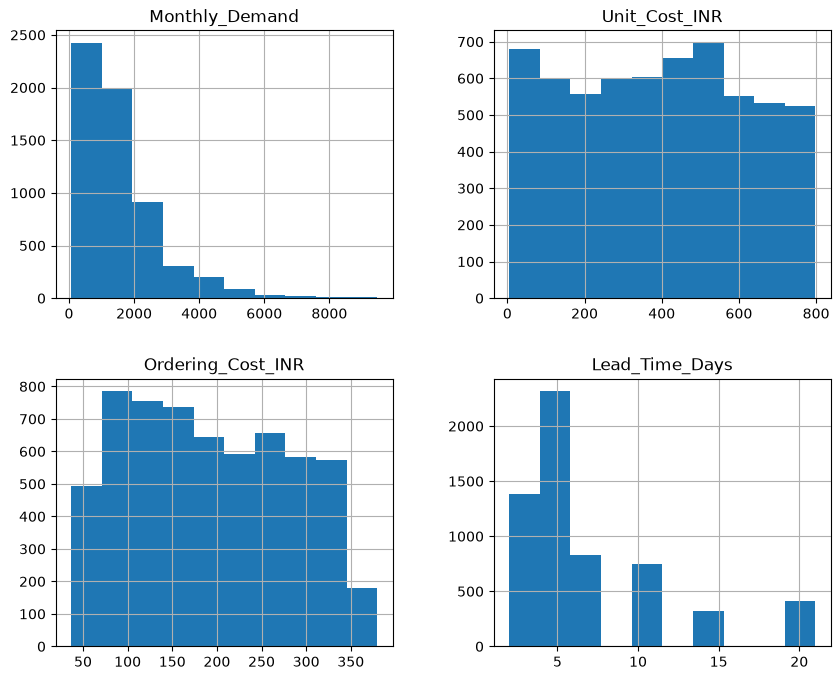

In [14]:
monthly_data[['Monthly_Demand','Unit_Cost_INR','Ordering_Cost_INR','Lead_Time_Days']].hist(figsize=(10,8))
plt.show()

univariate analysis on master table

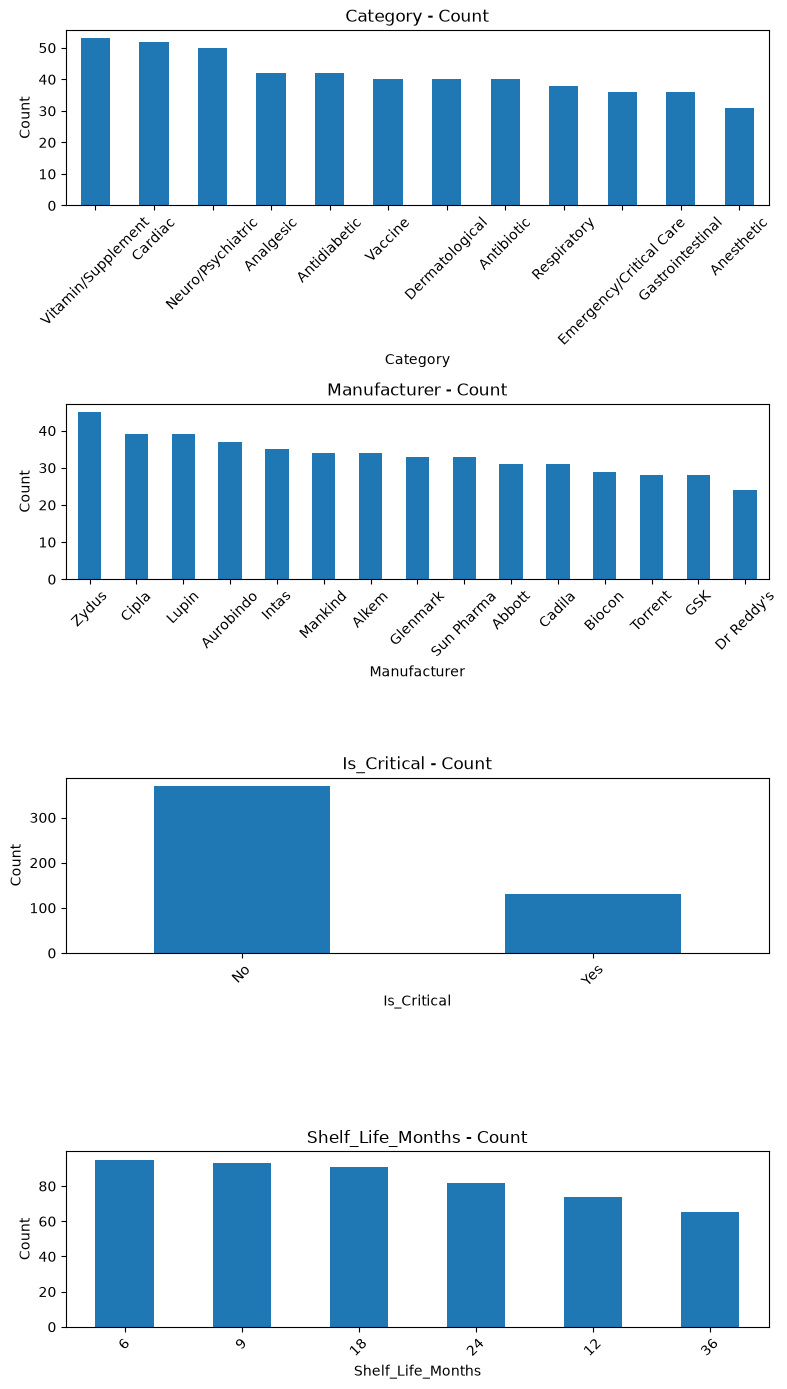

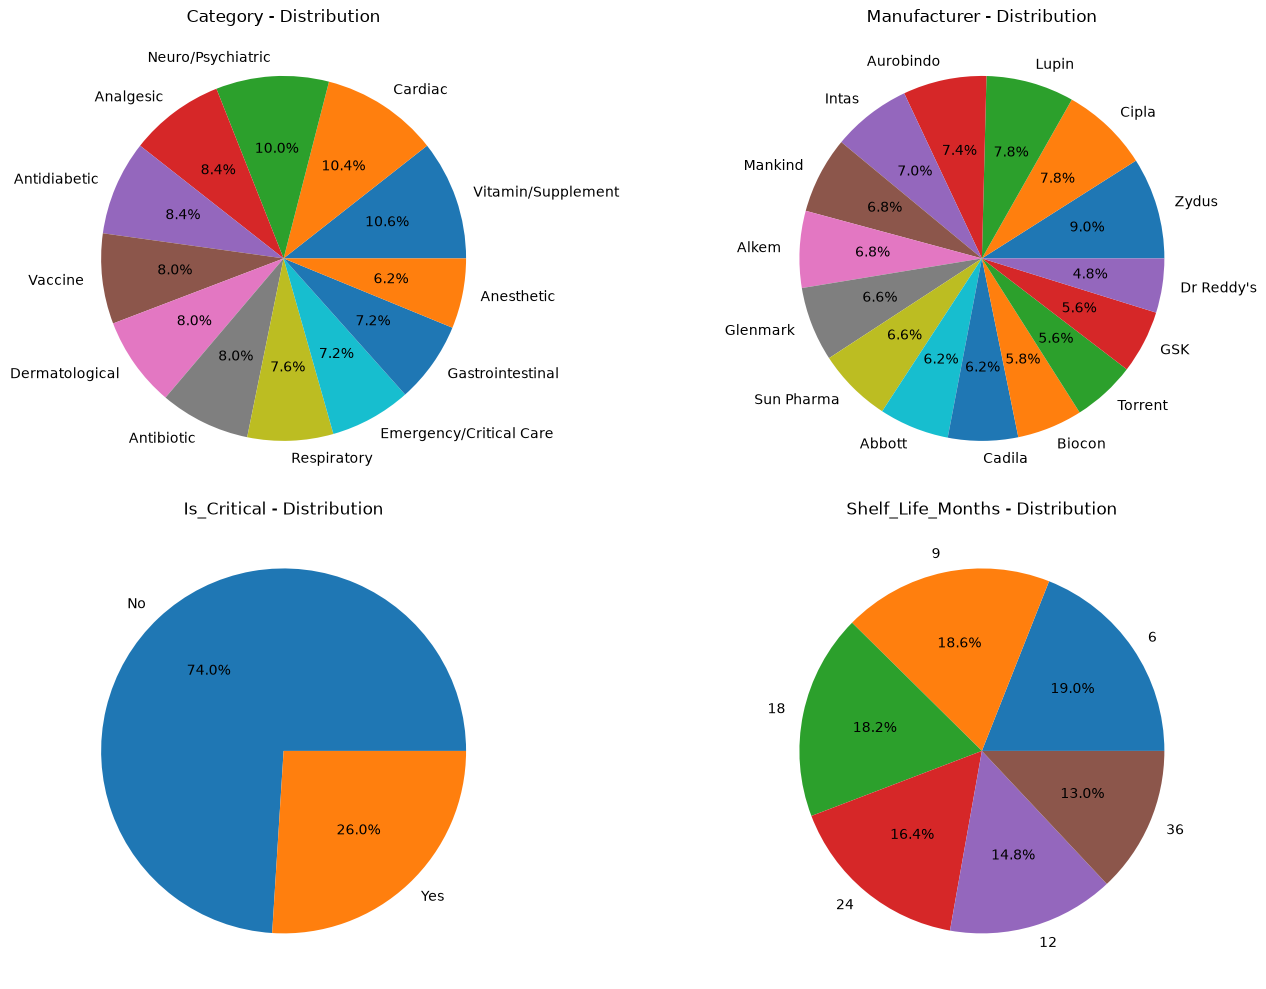

In [15]:
import matplotlib.pyplot as plt

cols = ['Category', 'Manufacturer', 'Is_Critical', 'Shelf_Life_Months']

fig, axes = plt.subplots(4,1, figsize=(8, 14))

for ax, col in zip(axes.flatten(), cols):
    medicine_info[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'{col} - Count')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), cols):
    medicine_info[col].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%')
    ax.set_title(f'{col} - Distribution')
   

plt.tight_layout()
plt.show()

merging and performing multivariate analysis

<a id="medicine v/s demand"></a>
### medicine v/s demand

In [16]:
merged = monthly_data.merge(medicine_info, on='Medicine_ID', how='left')

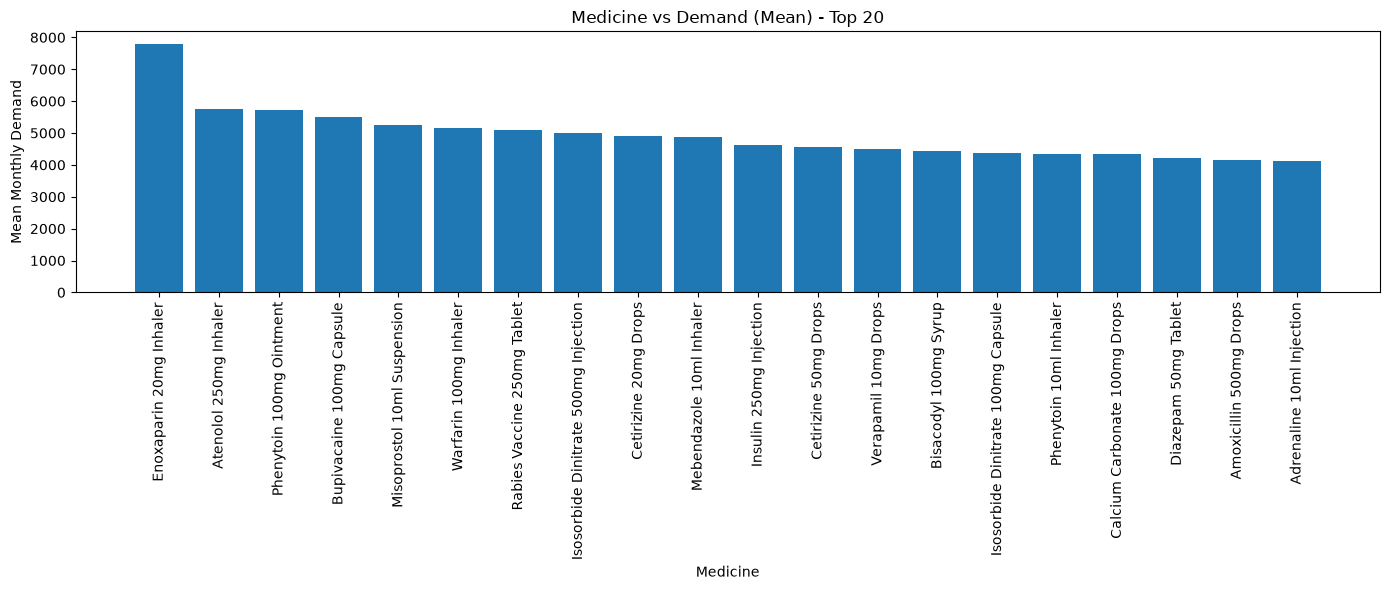

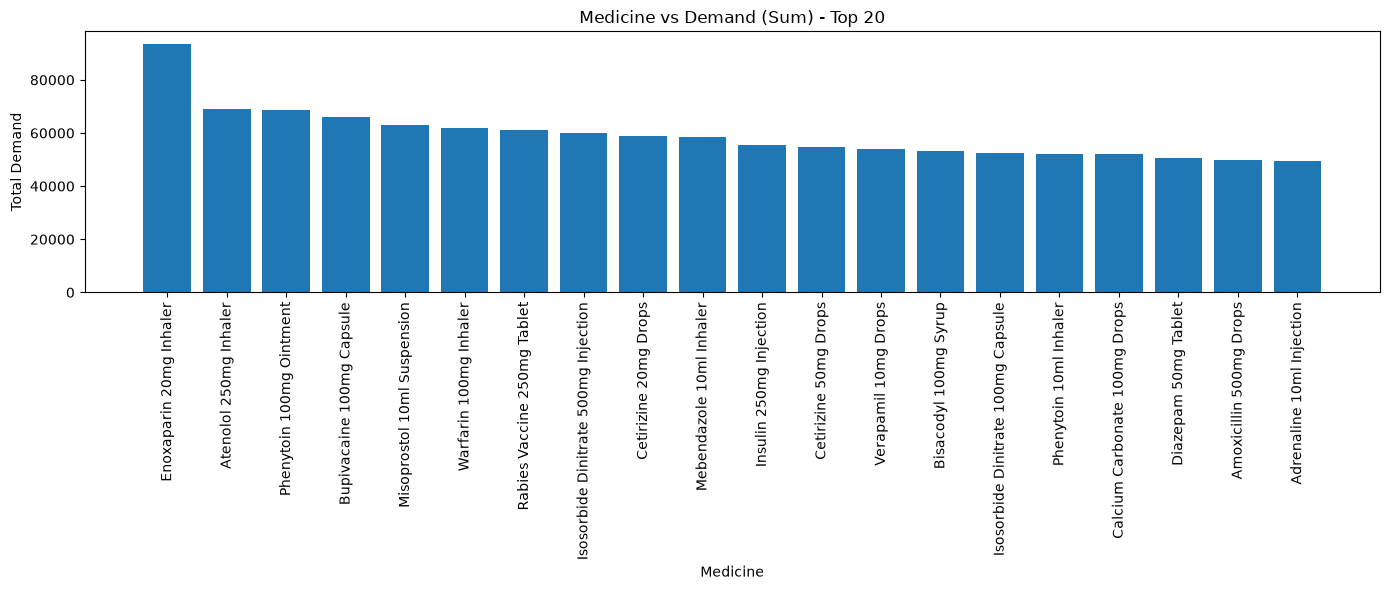

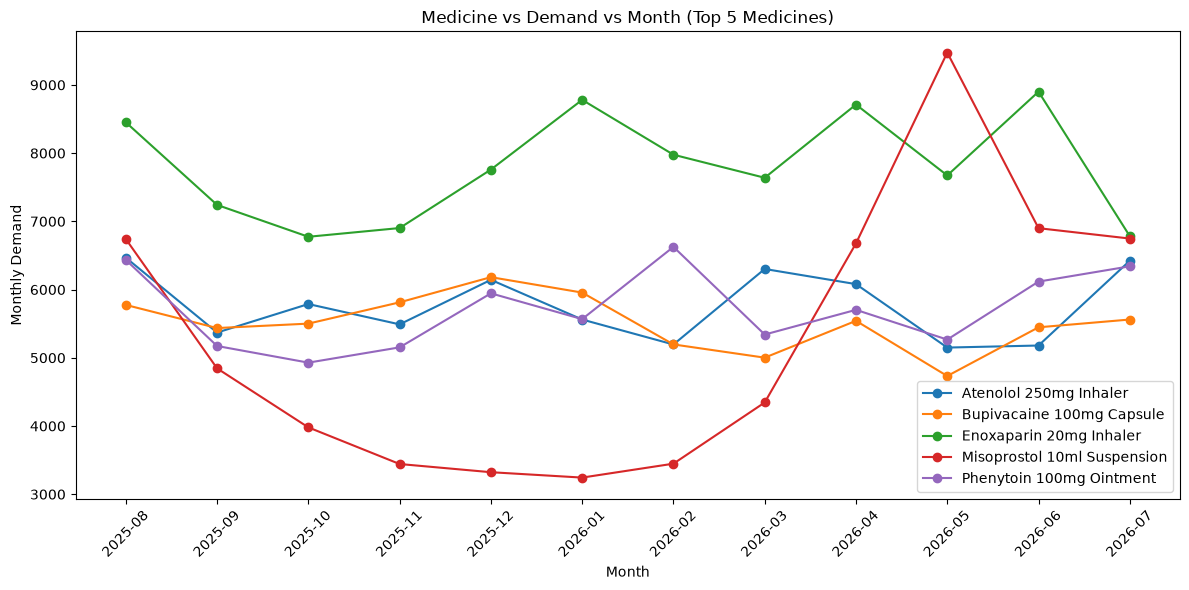

In [17]:
demand_by_medicine = merged.groupby('Medicine_Name')['Monthly_Demand'].agg(['mean', 'sum']).reset_index()

top_n = 20   
plot_data = demand_by_medicine.sort_values('mean', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['mean'])
plt.title(f'Medicine vs Demand (Mean) - Top {top_n}' if top_n else 'Medicine vs Demand (Mean)')
plt.xlabel('Medicine')
plt.ylabel('Mean Monthly Demand')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ---- Medicine vs Demand (Sum) ----
plot_data = demand_by_medicine.sort_values('sum', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['sum'])
plt.title(f'Medicine vs Demand (Sum) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Total Demand')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#  Medicine vs Demand vs Month (pivot + line plot)
top_medicines = demand_by_medicine.sort_values('sum', ascending=False).head(5)['Medicine_Name']

pivot = merged[merged['Medicine_Name'].isin(top_medicines)].pivot_table(
    index='Month', columns='Medicine_Name', values='Monthly_Demand', aggfunc='sum'
)

plt.figure(figsize=(12, 6))
for medicine in pivot.columns:
    plt.plot(pivot.index, pivot[medicine], marker='o', label=medicine)

plt.title('Medicine vs Demand vs Month (Top 5 Medicines)')
plt.xlabel('Month')
plt.ylabel('Monthly Demand')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<a id="medicine v/s opening stock"></a>
### medicine v/s opening stock

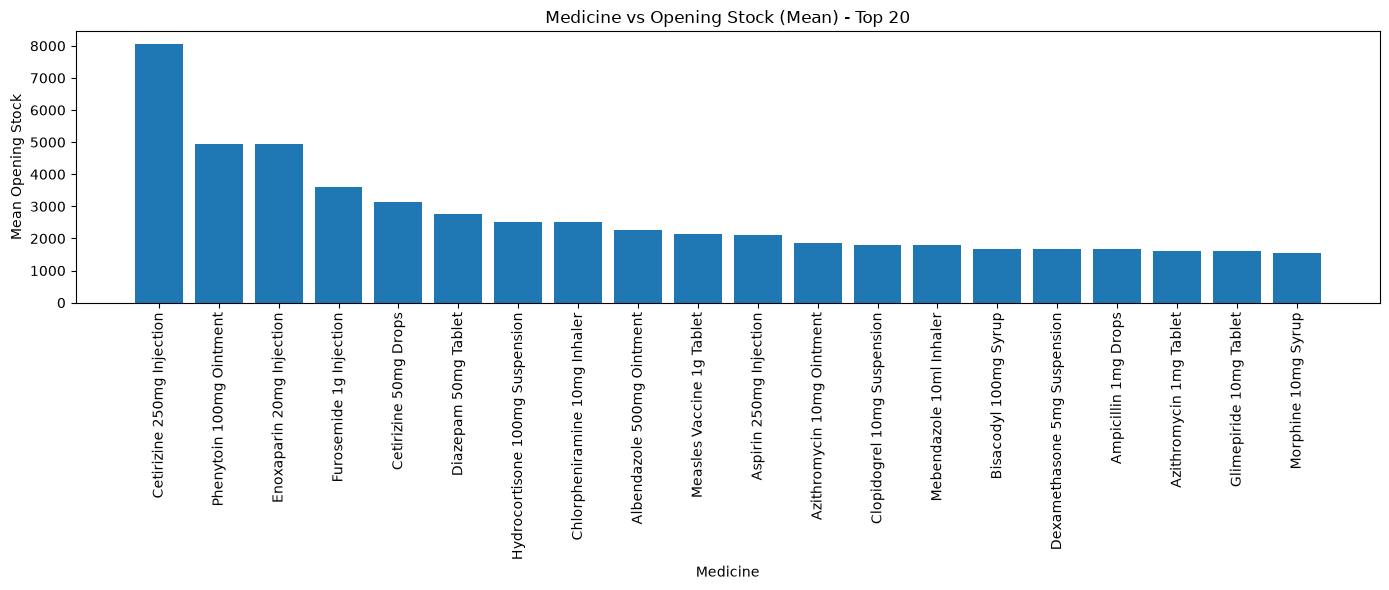

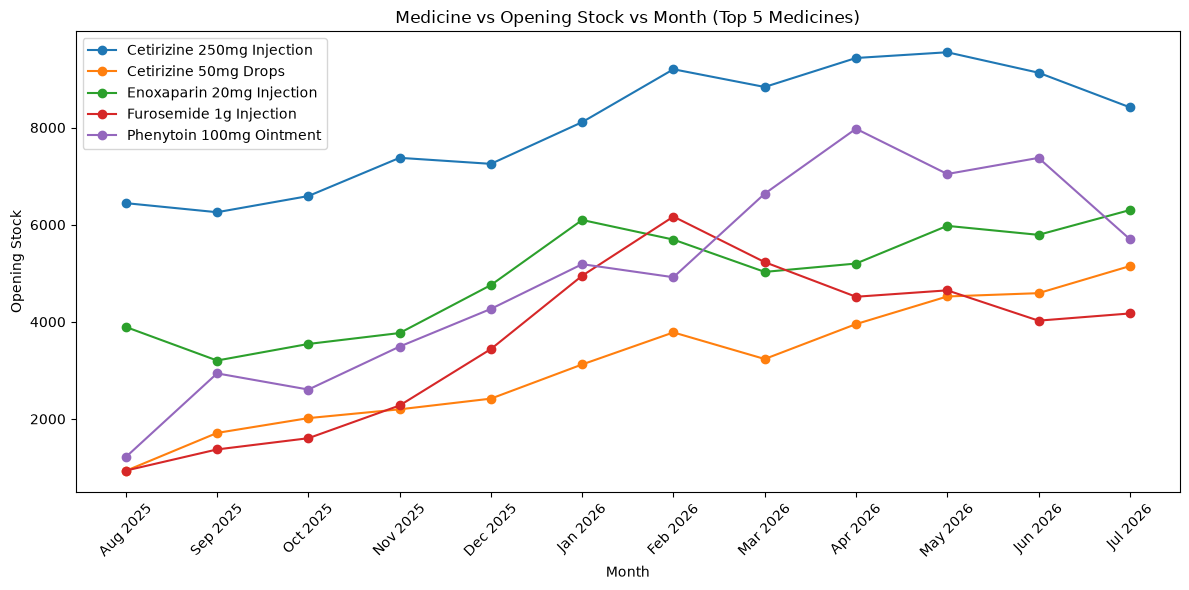

In [ ]:
merged['Month'] = pd.to_datetime(merged['Month'], format='%Y-%m')

#  Group by medicine -> mean opening stock
stock_by_medicine = merged.groupby('Medicine_Name')['Opening_Stock'].mean().reset_index()
stock_by_medicine.columns = ['Medicine_Name', 'mean']

# ---- Medicine vs Opening Stock (Mean) ----
top_n = 20
plot_data = stock_by_medicine.sort_values('mean', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['mean'])
plt.title(f'Medicine vs Opening Stock (Mean) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Mean Opening Stock')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Medicine vs Opening Stock vs Month (top 5 medicines by mean opening stock)
top_medicines = stock_by_medicine.sort_values('mean', ascending=False).head(5)['Medicine_Name']

pivot = merged[merged['Medicine_Name'].isin(top_medicines)].pivot_table(
    index='Month', columns='Medicine_Name', values='Opening_Stock', aggfunc='mean'
)
pivot = pivot.sort_index()

month_labels = pivot.index.strftime('%b %Y')

plt.figure(figsize=(12, 6))
for medicine in pivot.columns:
    plt.plot(month_labels, pivot[medicine], marker='o', label=medicine)

plt.title('Medicine vs Opening Stock vs Month (Top 5 Medicines)')
plt.xlabel('Month')
plt.ylabel('Opening Stock')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<a id="medicine v/s closing stock"></a>
### medicine v/s closing stock

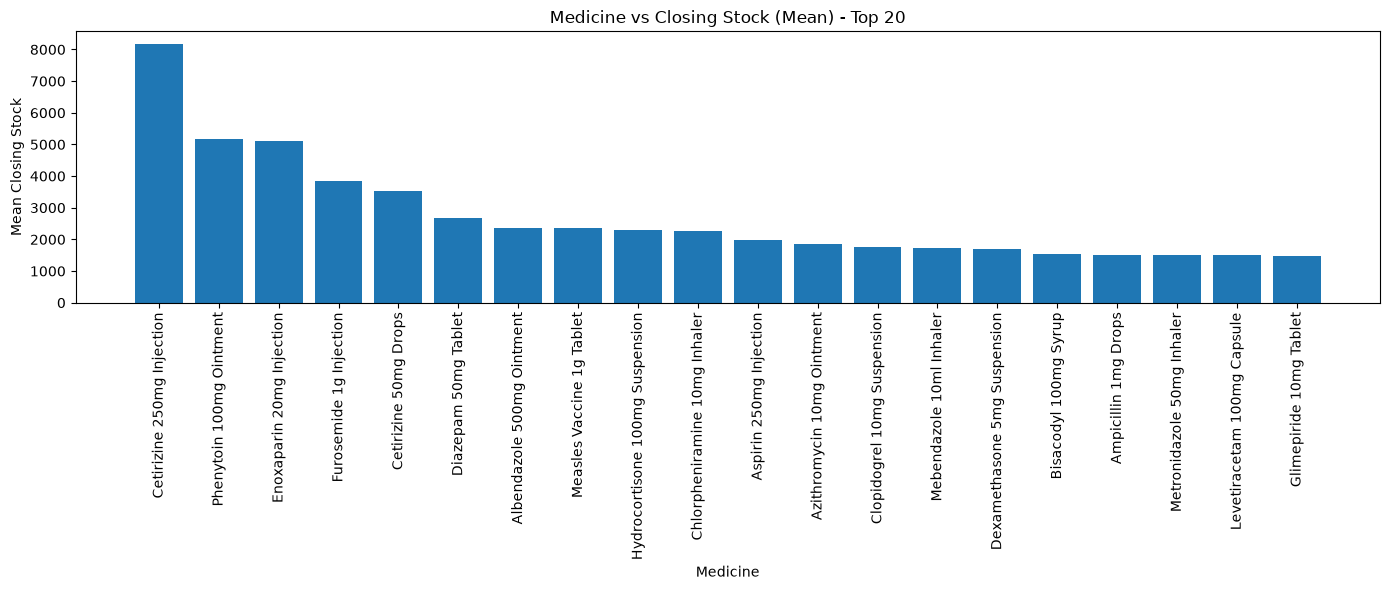

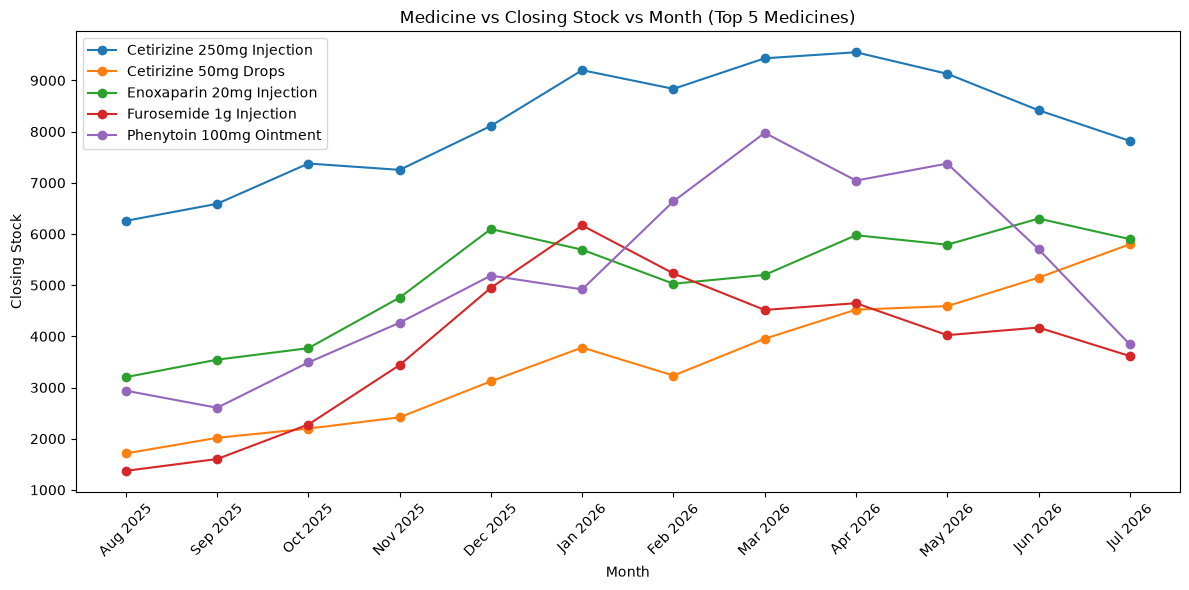

In [46]:
merged['Month'] = pd.to_datetime(merged['Month'], format='%Y-%m')
merged['Month_Label'] = merged['Month'].dt.strftime('%b %Y')

# Group by medicine -> mean and sum of closing stock
stock_by_medicine = merged.groupby('Medicine_Name')['Closing_Stock'].agg(['mean', 'sum']).reset_index()

# ---- Medicine vs Closing Stock (Mean) ----
top_n = 20
plot_data = stock_by_medicine.sort_values('mean', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['mean'])
plt.title(f'Medicine vs Closing Stock (Mean) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Mean Closing Stock')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



# Medicine vs Closing Stock vs Month (top 5 medicines)
top_medicines = stock_by_medicine.sort_values('sum', ascending=False).head(5)['Medicine_Name']

pivot = merged[merged['Medicine_Name'].isin(top_medicines)].pivot_table(
    index='Month', columns='Medicine_Name', values='Closing_Stock', aggfunc='sum'
)
pivot = pivot.sort_index()

month_labels = pivot.index.strftime('%b %Y')

plt.figure(figsize=(12, 6))
for medicine in pivot.columns:
    plt.plot(month_labels, pivot[medicine], marker='o', label=medicine)

plt.title('Medicine vs Closing Stock vs Month (Top 5 Medicines)')
plt.xlabel('Month')
plt.ylabel('Closing Stock')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<a id="medicine v/s restock"></a>
### medicine v/s restock

In [41]:
erged = monthly_data.merge(medicine_info, on='Medicine_ID', how='left')
merged['Month'] = pd.to_datetime(merged['Month'], format='%Y-%m')
merged['Month_Label'] = merged['Month'].dt.strftime('%b %Y')

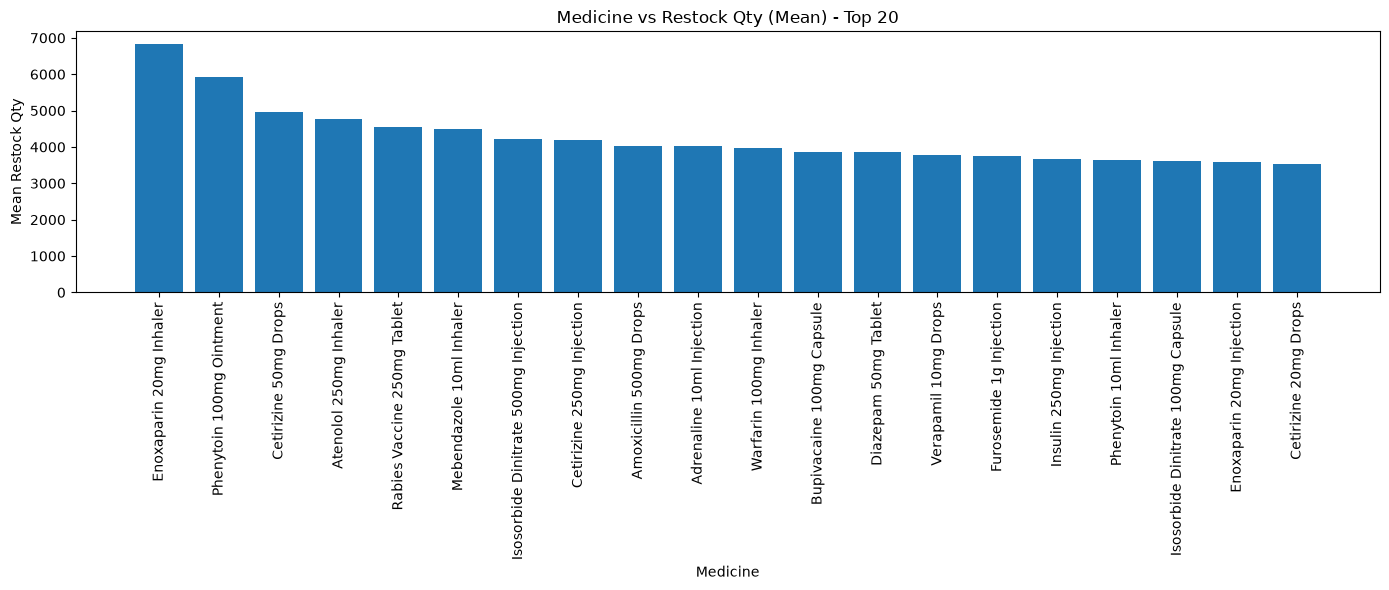

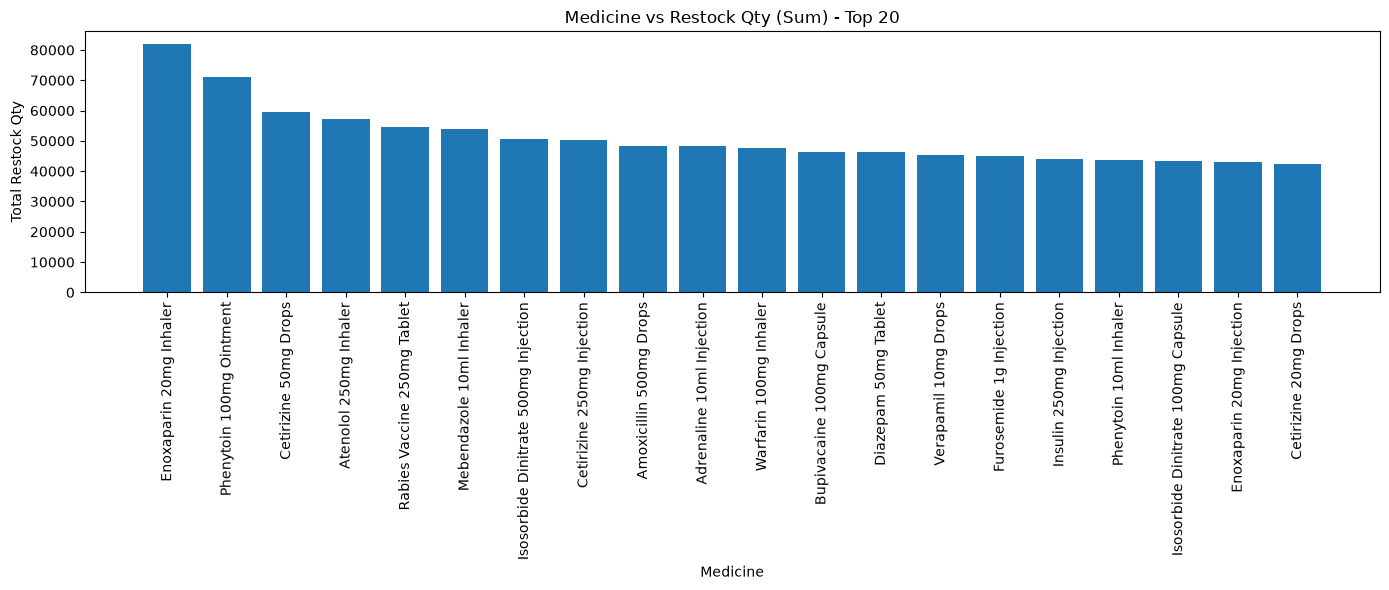

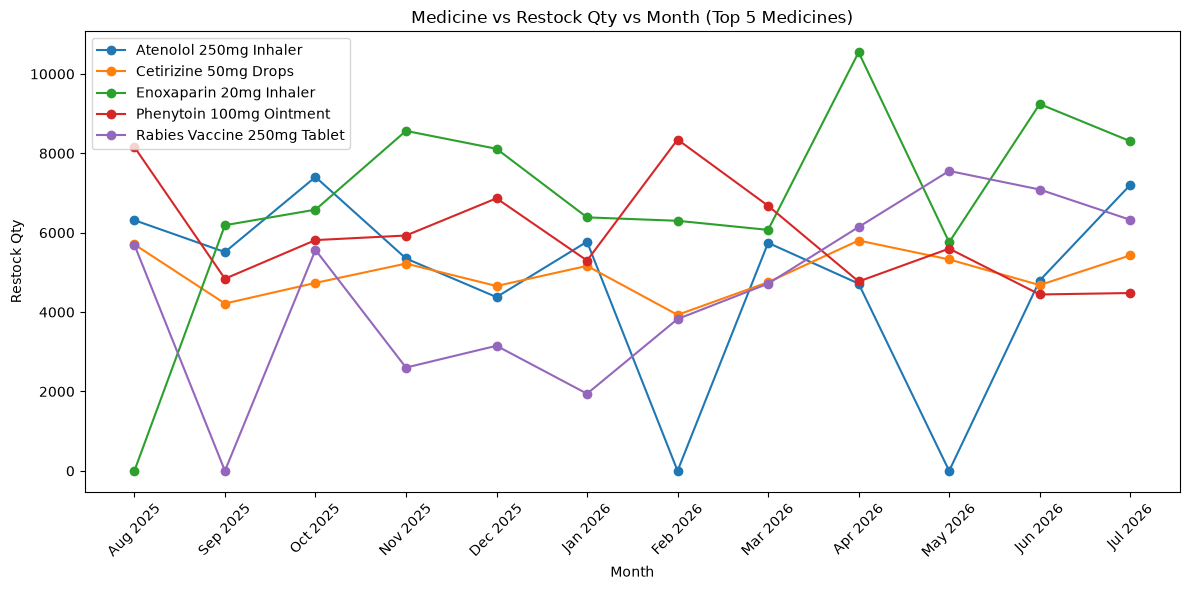

In [ ]:

restock_by_medicine = merged.groupby('Medicine_Name')['Restock_Qty'].agg(['mean', 'sum']).reset_index()

# ---- Medicine vs Restock Qty (Mean) ----
top_n = 20
plot_data = restock_by_medicine.sort_values('mean', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['mean'])
plt.title(f'Medicine vs Restock Qty (Mean) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Mean Restock Qty')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ---- Medicine vs Restock Qty (Sum) ----
plot_data = restock_by_medicine.sort_values('sum', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['sum'])
plt.title(f'Medicine vs Restock Qty (Sum) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Total Restock Qty')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#  Medicine vs Restock Qty vs Month (top 5 medicines)
top_medicines = restock_by_medicine.sort_values('sum', ascending=False).head(5)['Medicine_Name']

pivot = merged[merged['Medicine_Name'].isin(top_medicines)].pivot_table(
    index='Month', columns='Medicine_Name', values='Restock_Qty', aggfunc='sum'
)
pivot = pivot.sort_index()

month_labels = pivot.index.strftime('%b %Y')

plt.figure(figsize=(12, 6))
for medicine in pivot.columns:
    plt.plot(month_labels, pivot[medicine], marker='o', label=medicine)

plt.title('Medicine vs Restock Qty vs Month (Top 5 Medicines)')
plt.xlabel('Month')
plt.ylabel('Restock Qty')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<a id="medicine v/s demand fulfilled"></a>
### medicine v/s demand fulfilled

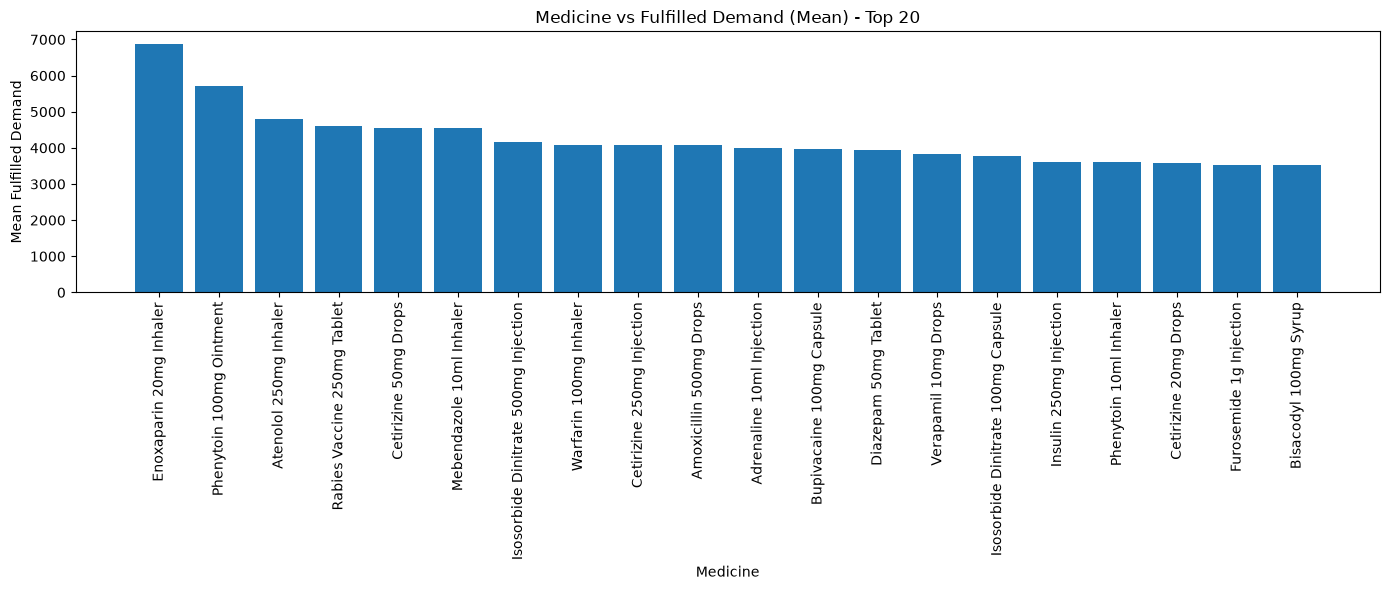

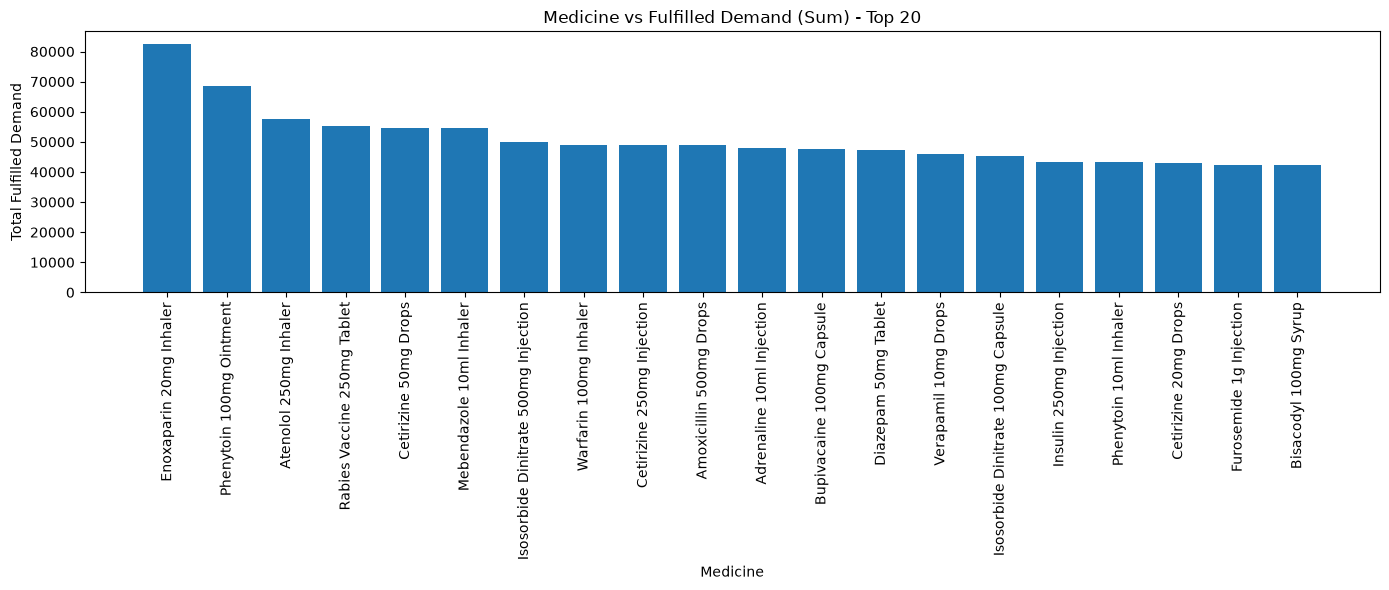

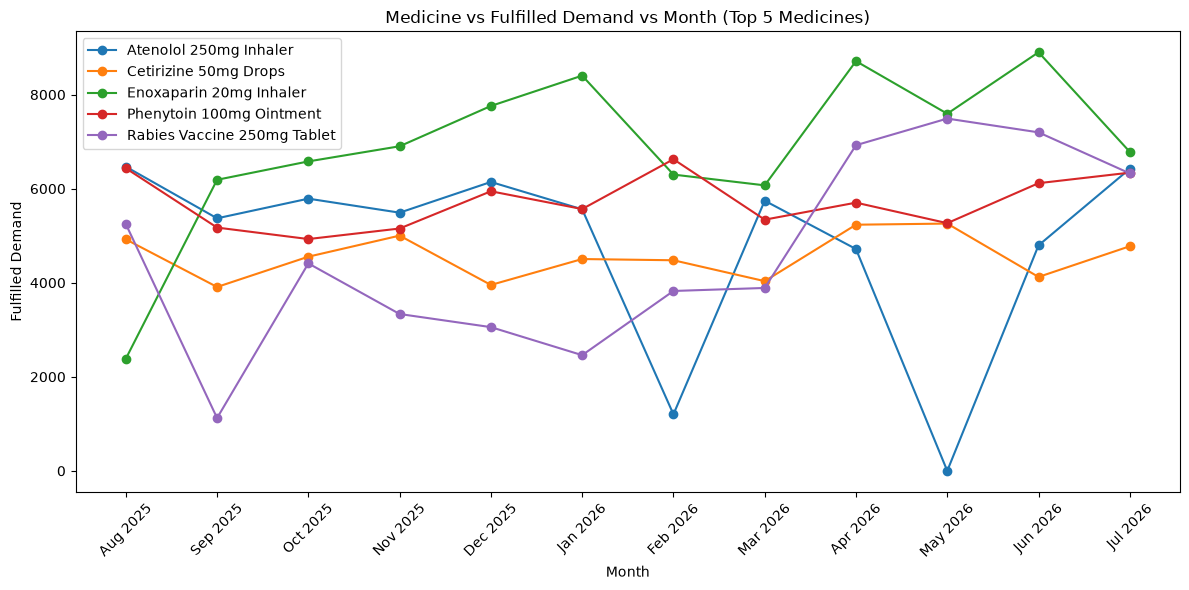

In [44]:

fulfilled_by_medicine = merged.groupby('Medicine_Name')['Fulfilled_Demand'].agg(['mean', 'sum']).reset_index()

# ---- Medicine vs Fulfilled Demand (Mean) ----
top_n = 20
plot_data = fulfilled_by_medicine.sort_values('mean', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['mean'])
plt.title(f'Medicine vs Fulfilled Demand (Mean) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Mean Fulfilled Demand')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ---- Medicine vs Fulfilled Demand (Sum) ----
plot_data = fulfilled_by_medicine.sort_values('sum', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['sum'])
plt.title(f'Medicine vs Fulfilled Demand (Sum) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Total Fulfilled Demand')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Medicine vs Fulfilled Demand vs Month (top 5 medicines)
top_medicines = fulfilled_by_medicine.sort_values('sum', ascending=False).head(5)['Medicine_Name']

pivot = merged[merged['Medicine_Name'].isin(top_medicines)].pivot_table(
    index='Month', columns='Medicine_Name', values='Fulfilled_Demand', aggfunc='sum'
)
pivot = pivot.sort_index()
month_labels = pivot.index.strftime('%b %Y')

plt.figure(figsize=(12, 6))
for medicine in pivot.columns:
    plt.plot(month_labels, pivot[medicine], marker='o', label=medicine)

plt.title('Medicine vs Fulfilled Demand vs Month (Top 5 Medicines)')
plt.xlabel('Month')
plt.ylabel('Fulfilled Demand')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<a id="medicine v/s stock out"></a>
### medicine v/s stock out

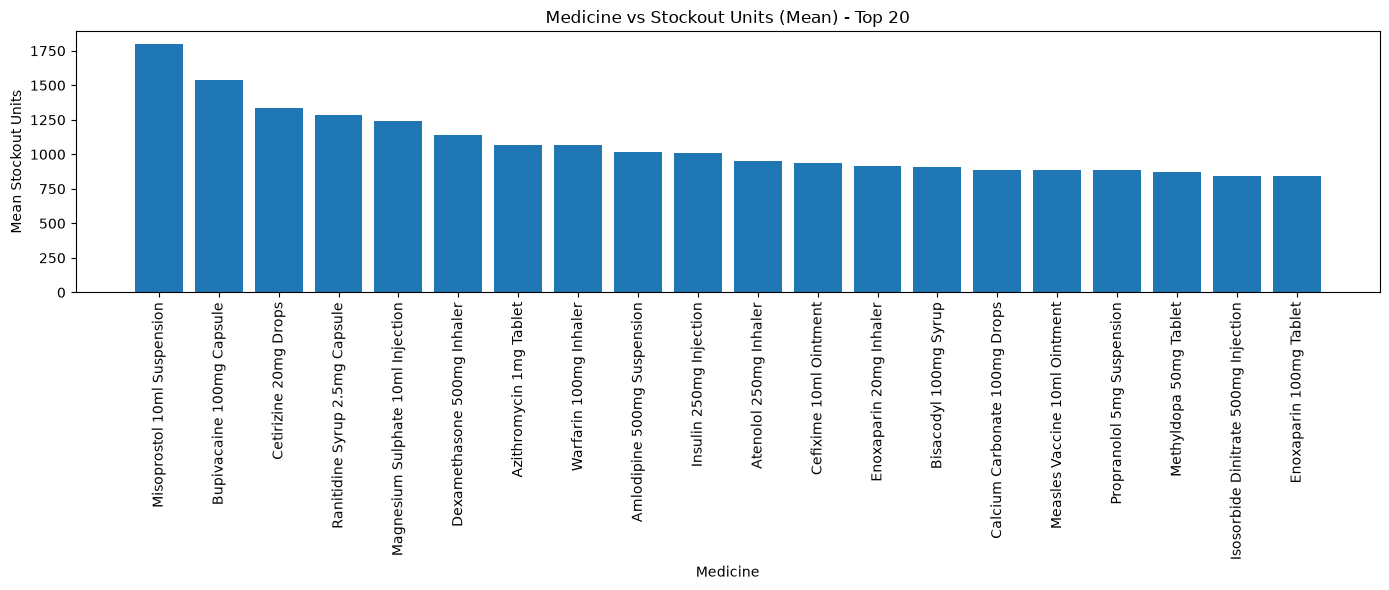

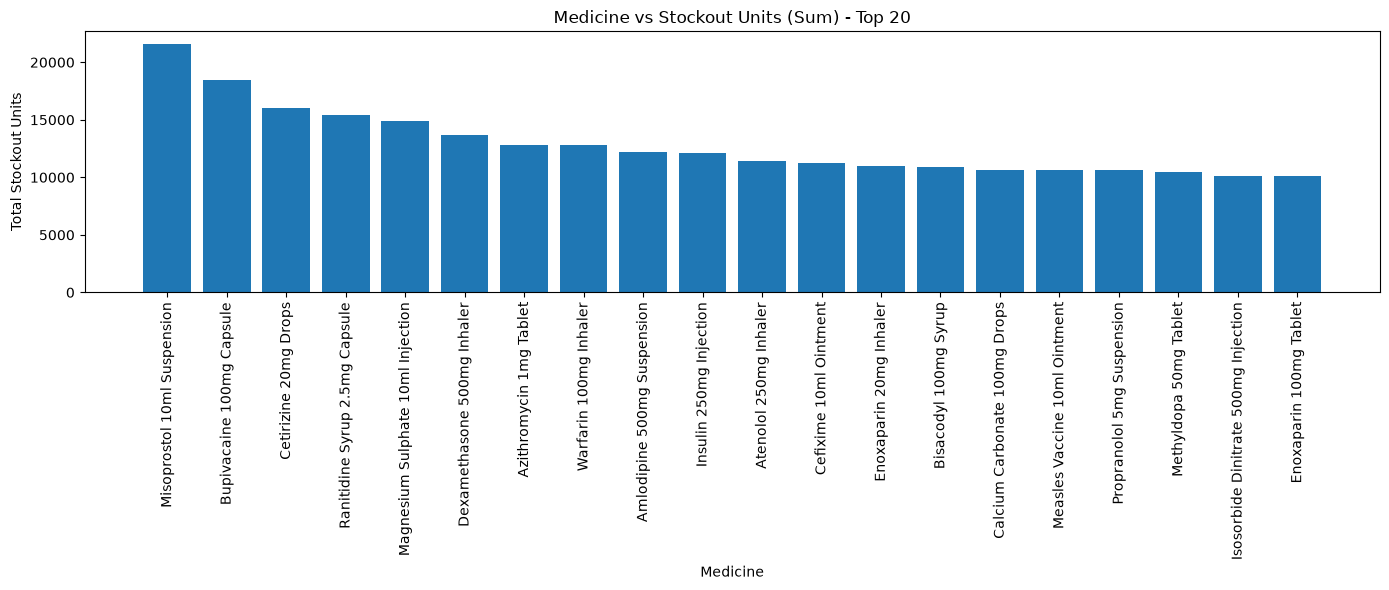

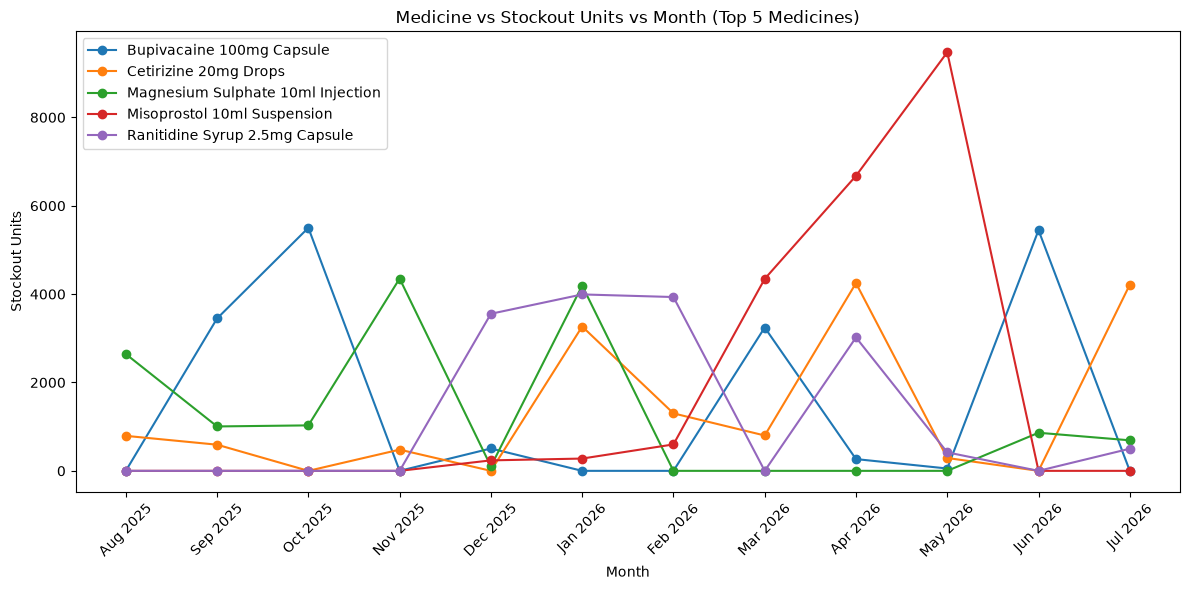

In [47]:
# 2. Group by medicine -> mean and sum of stockout units
stockout_by_medicine = merged.groupby('Medicine_Name')['Stockout_Units'].agg(['mean', 'sum']).reset_index()

# ---- Medicine vs Stockout Units (Mean) ----
top_n = 20
plot_data = stockout_by_medicine.sort_values('mean', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['mean'])
plt.title(f'Medicine vs Stockout Units (Mean) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Mean Stockout Units')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ---- Medicine vs Stockout Units (Sum) ----
plot_data = stockout_by_medicine.sort_values('sum', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['sum'])
plt.title(f'Medicine vs Stockout Units (Sum) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Total Stockout Units')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 3. Medicine vs Stockout Units vs Month (top 5 medicines)
top_medicines = stockout_by_medicine.sort_values('sum', ascending=False).head(5)['Medicine_Name']

pivot = merged[merged['Medicine_Name'].isin(top_medicines)].pivot_table(
    index='Month', columns='Medicine_Name', values='Stockout_Units', aggfunc='sum'
)
pivot = pivot.sort_index()
month_labels = pivot.index.strftime('%b %Y')

plt.figure(figsize=(12, 6))
for medicine in pivot.columns:
    plt.plot(month_labels, pivot[medicine], marker='o', label=medicine)

plt.title('Medicine vs Stockout Units vs Month (Top 5 Medicines)')
plt.xlabel('Month')
plt.ylabel('Stockout Units')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Key finding: Misoprostol 10ml Suspension has both the highest average (1,801/month) and total (21,609) stockout units — worth flagging for review. In the monthly trend, notice its stockouts spike sharply in May 2026 (~9,500 units) — that's a much bigger jump than the other top-5 medicines show in any single month, which stands out as an anomaly worth investigating (possible supply disruption or demand surge that month).

<a id="medicine v/s lead time"></a>
### medicine v/s lead time

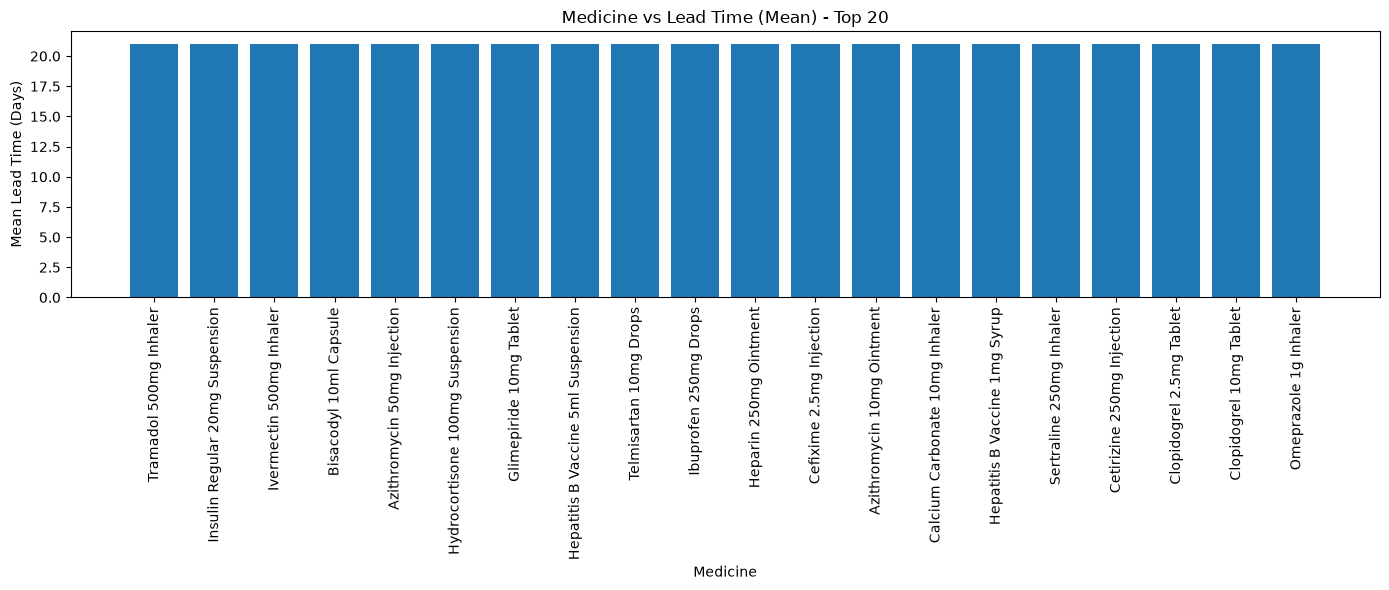

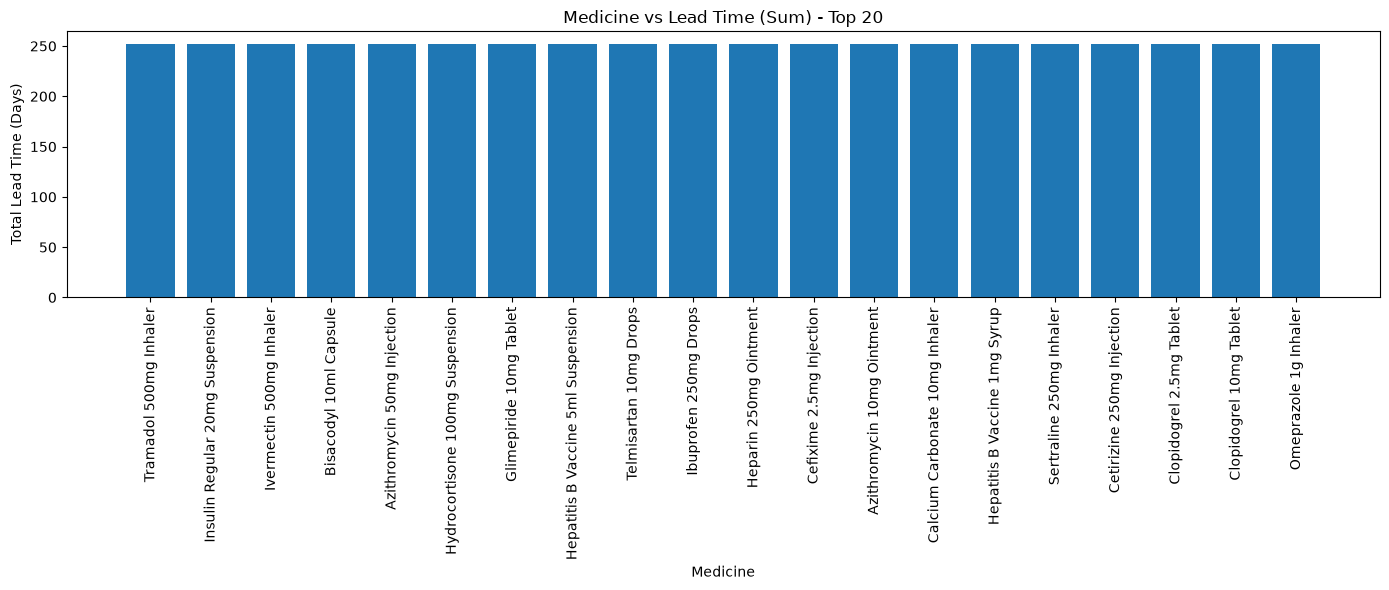

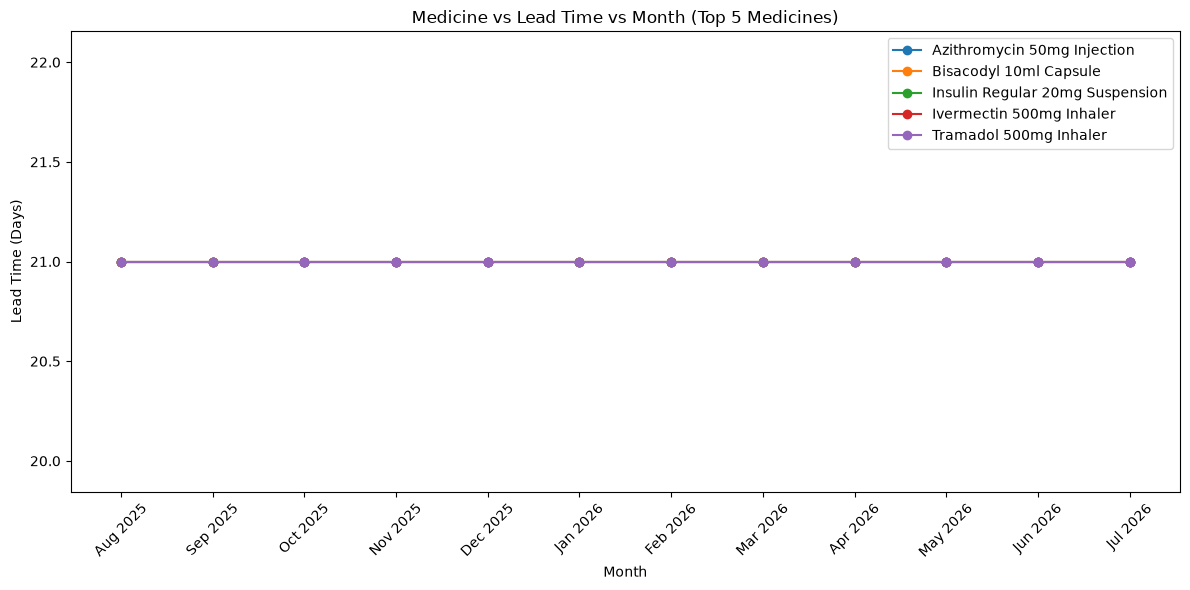

In [ ]:

leadtime_by_medicine = merged.groupby('Medicine_Name')['Lead_Time_Days'].agg(['mean', 'sum']).reset_index()

# ---- Medicine vs Lead Time (Mean) ----
top_n = 20
plot_data = leadtime_by_medicine.sort_values('mean', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['mean'])
plt.title(f'Medicine vs Lead Time (Mean) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Mean Lead Time (Days)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ---- Medicine vs Lead Time (Sum) ----
plot_data = leadtime_by_medicine.sort_values('sum', ascending=False).head(top_n)

plt.figure(figsize=(14, 6))
plt.bar(plot_data['Medicine_Name'], plot_data['sum'])
plt.title(f'Medicine vs Lead Time (Sum) - Top {top_n}')
plt.xlabel('Medicine')
plt.ylabel('Total Lead Time (Days)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



<a id="medicine v/s ordering cost"></a>
### medicine v/s ordering cost

top 5 medicines whose values rose by the year and whose value fall by most through the year


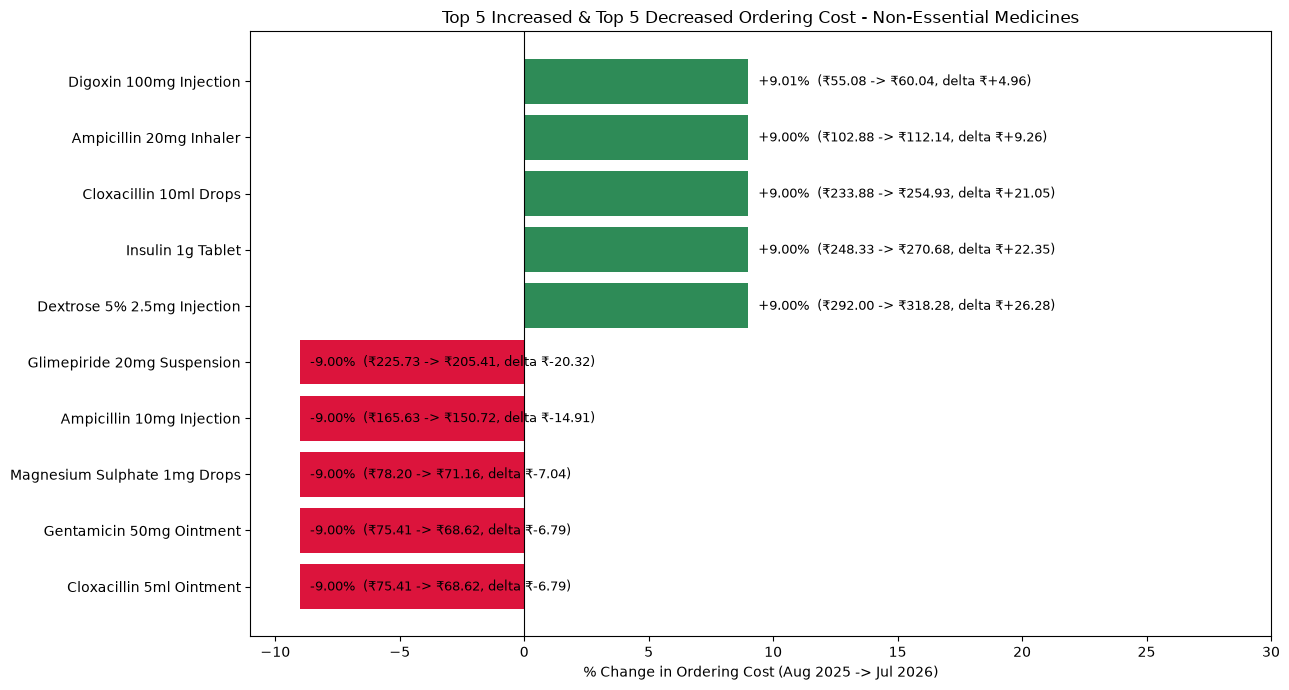

In [23]:

noncrit = merged[merged['Is_Critical'] == 'No']

# 2. Compute first vs last month value, absolute and % change
first_month, last_month = noncrit['Month'].min(), noncrit['Month'].max()
first_vals = noncrit[noncrit['Month']==first_month].set_index('Medicine_Name')['Ordering_Cost_INR']
last_vals  = noncrit[noncrit['Month']==last_month].set_index('Medicine_Name')['Ordering_Cost_INR']

change = pd.DataFrame({'first': first_vals, 'last': last_vals})
change['abs_change'] = change['last'] - change['first']
change['pct_change'] = change['abs_change'] / change['first'] * 100

top5_inc = change.sort_values('pct_change', ascending=False).head(5)
top5_dec = change.sort_values('pct_change').head(5)
combined = pd.concat([top5_inc, top5_dec]).sort_values('pct_change')

# 3. Horizontal diverging bar chart with exact-value labels
fig, ax = plt.subplots(figsize=(13, 7))
colors = ['crimson' if v < 0 else 'seagreen' for v in combined['pct_change']]
ax.barh(range(len(combined)), combined['pct_change'], color=colors)

ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined.index)

for i, (idx, row) in enumerate(combined.iterrows()):
    label = f"{row['pct_change']:+.2f}%  (₹{row['first']:.2f} -> ₹{row['last']:.2f}, delta ₹{row['abs_change']:+.2f})"
    ax.text(row['pct_change'] + 0.4, i, label, va='center', ha='left', fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('% Change in Ordering Cost (Aug 2025 -> Jul 2026)')
ax.set_title('Top 5 Increased & Top 5 Decreased Ordering Cost - Non-Essential Medicines')
ax.set_xlim(-11, 30)
plt.tight_layout()
plt.show()

category vs monthly demand


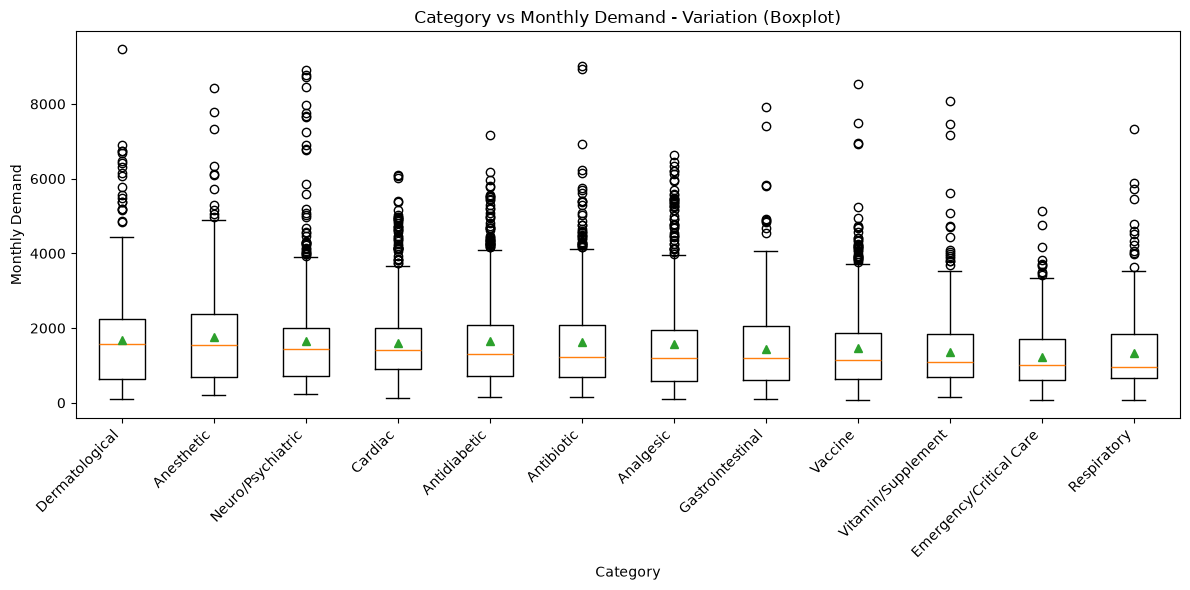

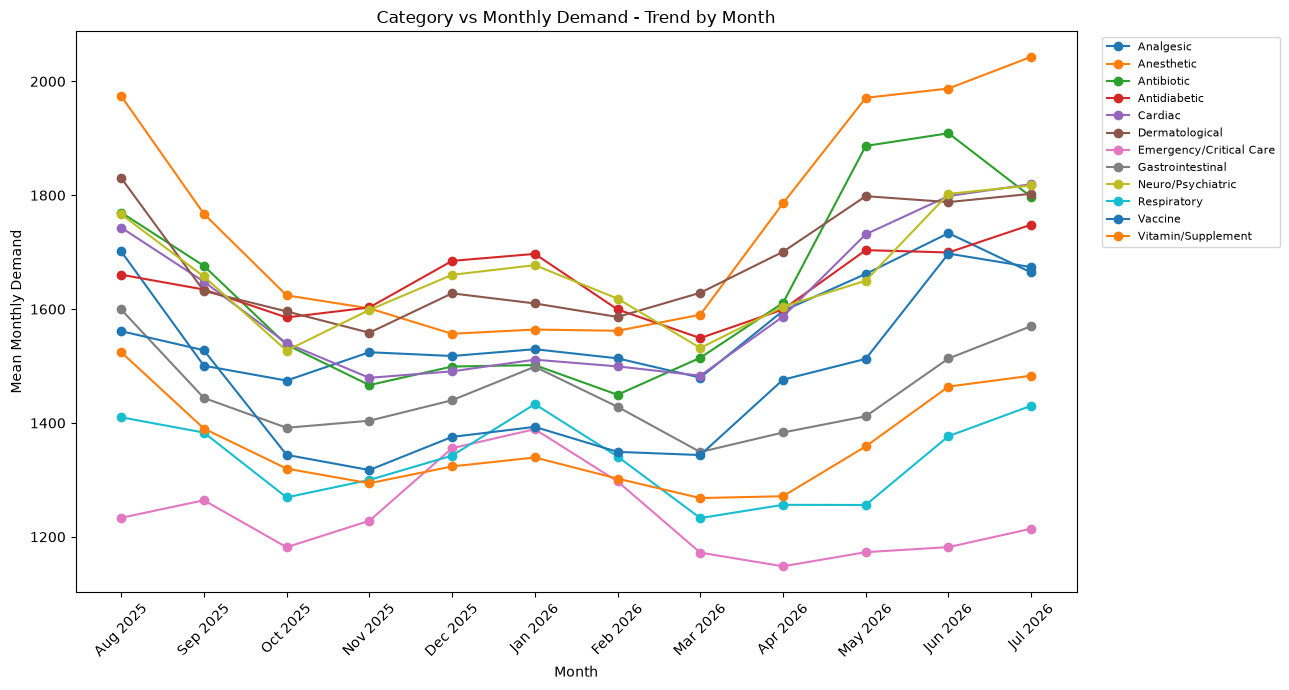

In [25]:

cat_order = merged.groupby('Category')['Monthly_Demand'].median().sort_values(ascending=False).index
data_by_cat = [merged[merged['Category']==c]['Monthly_Demand'].values for c in cat_order]

fig, ax = plt.subplots(figsize=(12,6))
ax.boxplot(data_by_cat, tick_labels=cat_order, showmeans=True)
ax.set_title('Category vs Monthly Demand - Variation (Boxplot)')
ax.set_xlabel('Category'); ax.set_ylabel('Monthly Demand')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




pivot = merged.pivot_table(index='Month', columns='Category', values='Monthly_Demand', aggfunc='mean').sort_index()
month_labels = pivot.index.strftime('%b %Y')

plt.figure(figsize=(13,7))
for cat in pivot.columns:
    plt.plot(month_labels, pivot[cat], marker='o', label=cat)
plt.title('Category vs Monthly Demand - Trend by Month')
plt.xlabel('Month'); plt.ylabel('Mean Monthly Demand')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

category v/s total demand top 5 and their share


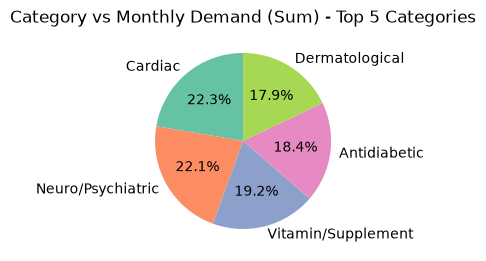

In [28]:


cat_sum = merged.groupby('Category')['Monthly_Demand'].sum().sort_values(ascending=False)
top5 = cat_sum.head(5)

plt.figure(figsize=(4,4))
plt.pie(top5, labels=top5.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
plt.title('Category vs Monthly Demand (Sum) - Top 5 Categories')
plt.tight_layout()
plt.show()

category v/s demand fulfilled


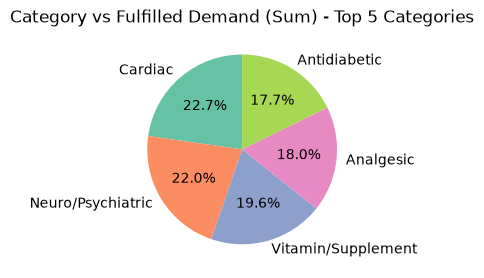

In [30]:


cat_sum = merged.groupby('Category')['Fulfilled_Demand'].sum().sort_values(ascending=False)
top5 = cat_sum.head(5)

plt.figure(figsize=(4,4))
plt.pie(top5, labels=top5.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
plt.title('Category vs Fulfilled Demand (Sum) - Top 5 Categories')
plt.tight_layout()
plt.show()

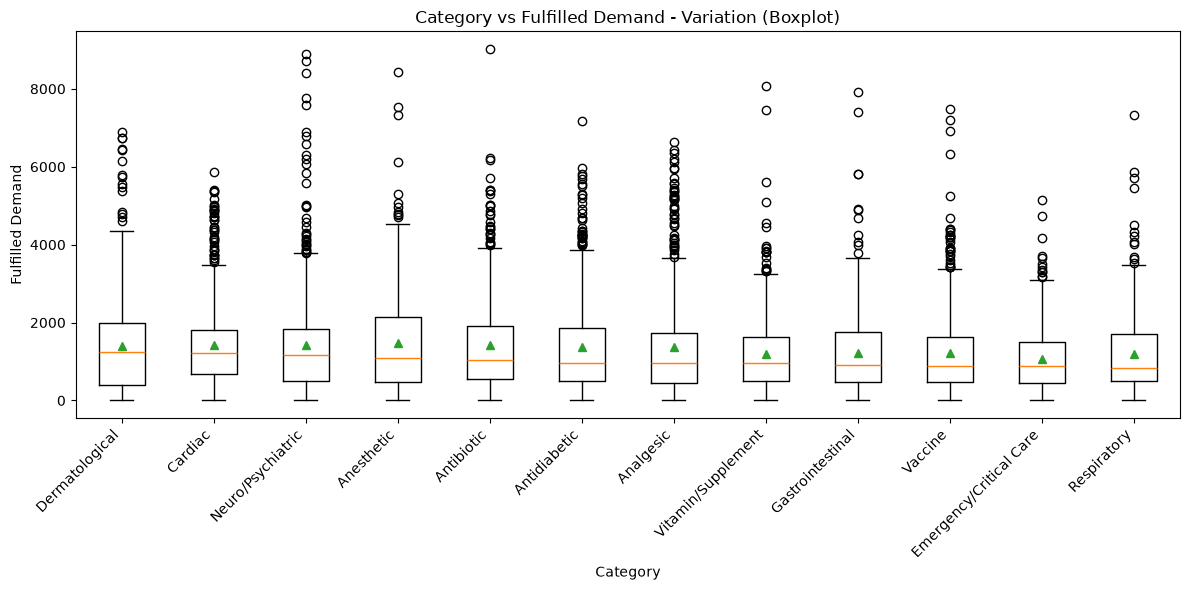

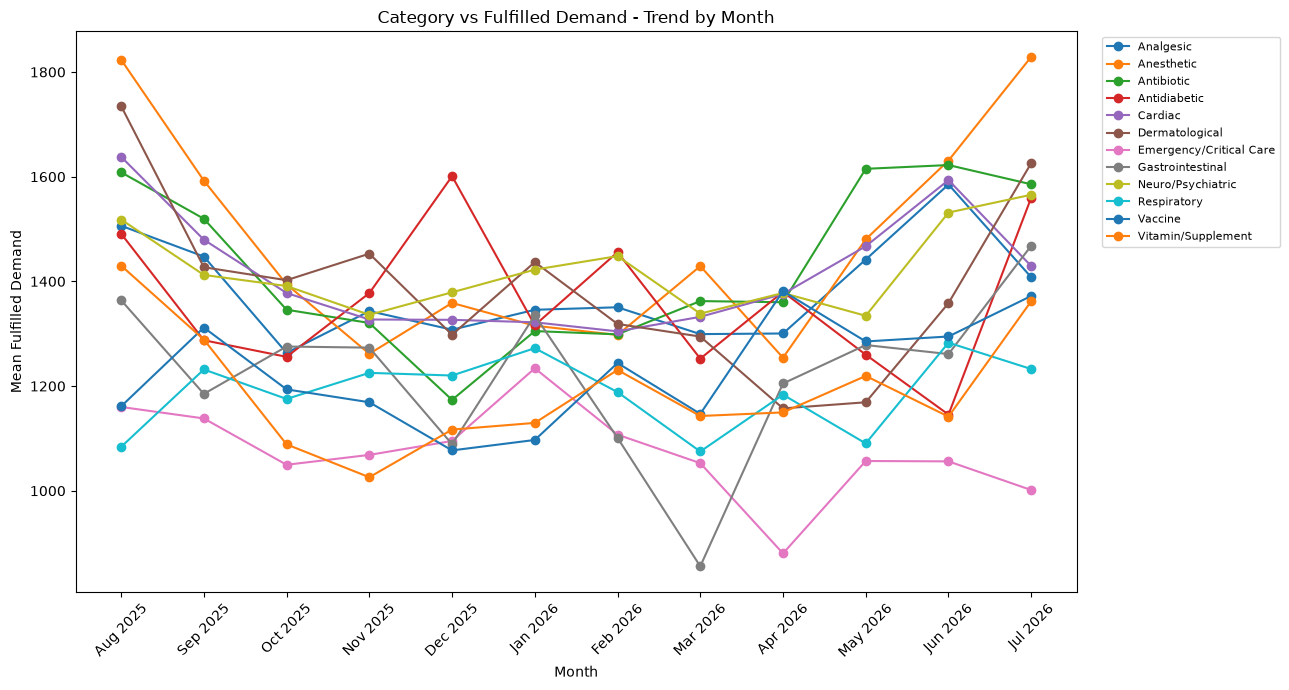

In [32]:

cat_order = merged.groupby('Category')['Fulfilled_Demand'].median().sort_values(ascending=False).index
data_by_cat = [merged[merged['Category']==c]['Fulfilled_Demand'].values for c in cat_order]
fig, ax = plt.subplots(figsize=(12,6))
ax.boxplot(data_by_cat, tick_labels=cat_order, showmeans=True)
ax.set_title('Category vs Fulfilled Demand - Variation (Boxplot)')
ax.set_xlabel('Category'); ax.set_ylabel('Fulfilled Demand')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---- 3. Month-wise trend per category ----
pivot = merged.pivot_table(index='Month', columns='Category', values='Fulfilled_Demand', aggfunc='mean').sort_index()
month_labels = pivot.index.strftime('%b %Y')
plt.figure(figsize=(13,7))
for cat in pivot.columns:
    plt.plot(month_labels, pivot[cat], marker='o', label=cat)
plt.title('Category vs Fulfilled Demand - Trend by Month')
plt.xlabel('Month'); plt.ylabel('Mean Fulfilled Demand')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

category v/s stockout


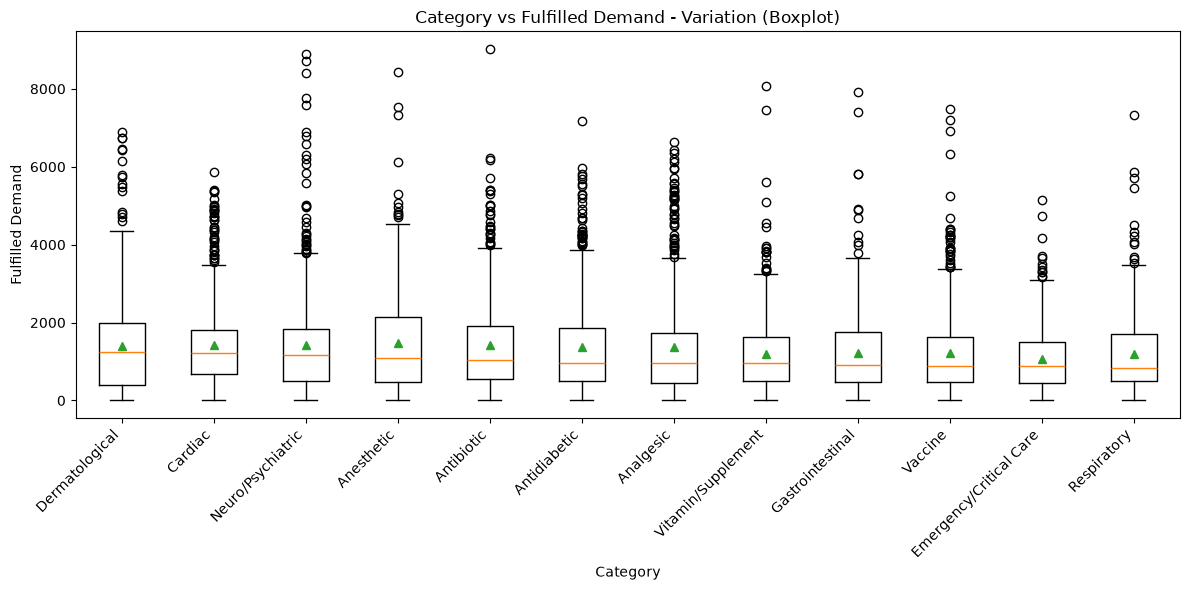

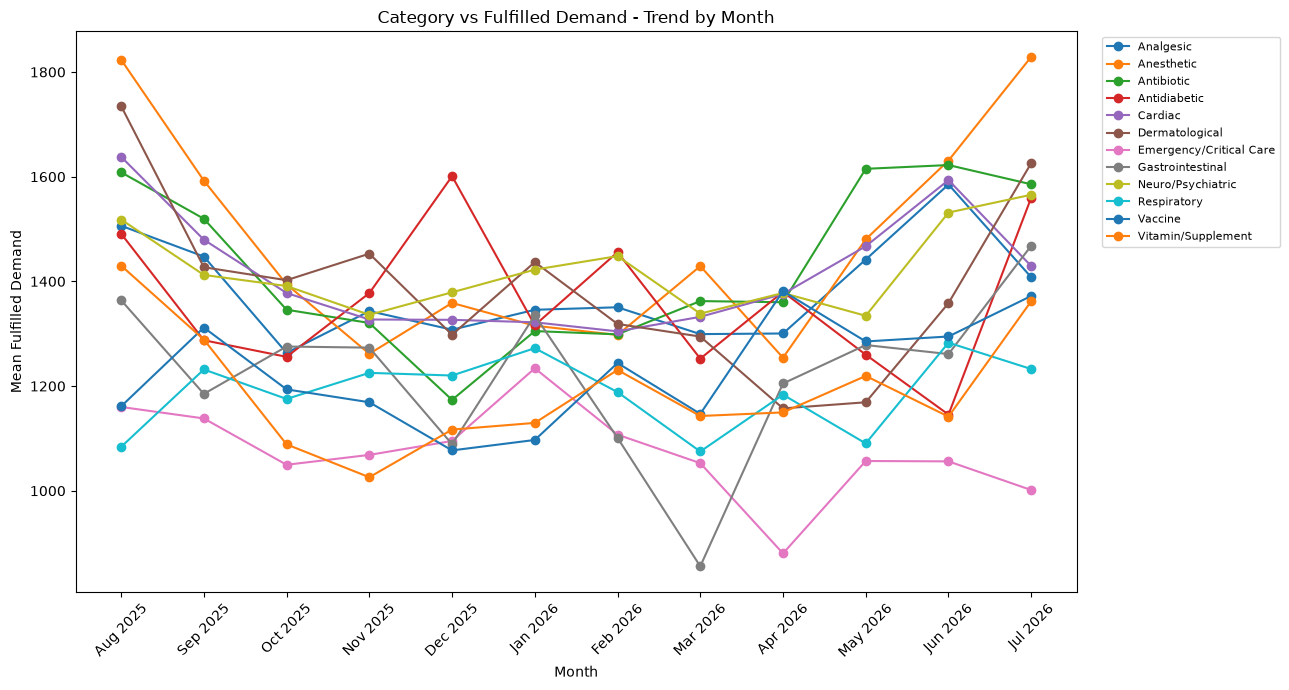

In [34]:

cat_order = merged.groupby('Category')['Fulfilled_Demand'].median().sort_values(ascending=False).index
data_by_cat = [merged[merged['Category']==c]['Fulfilled_Demand'].values for c in cat_order]
fig, ax = plt.subplots(figsize=(12,6))
ax.boxplot(data_by_cat, tick_labels=cat_order, showmeans=True)
ax.set_title('Category vs Fulfilled Demand - Variation (Boxplot)')
ax.set_xlabel('Category'); ax.set_ylabel('Fulfilled Demand')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


pivot = merged.pivot_table(index='Month', columns='Category', values='Fulfilled_Demand', aggfunc='mean').sort_index()
month_labels = pivot.index.strftime('%b %Y')
plt.figure(figsize=(13,7))
for cat in pivot.columns:
    plt.plot(month_labels, pivot[cat], marker='o', label=cat)
plt.title('Category vs Fulfilled Demand - Trend by Month')
plt.xlabel('Month'); plt.ylabel('Mean Fulfilled Demand')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

category vs stockout


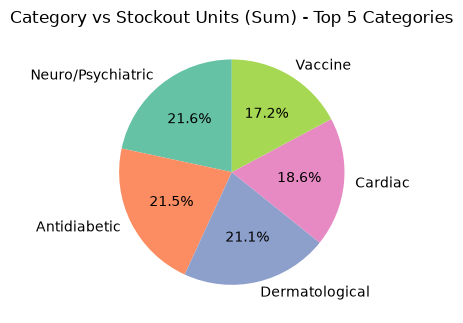

In [36]:


cat_sum = merged.groupby('Category')['Stockout_Units'].sum().sort_values(ascending=False)
top5 = cat_sum.head(5)

plt.figure(figsize=(4,4))
plt.pie(top5, labels=top5.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
plt.title('Category vs Stockout Units (Sum) - Top 5 Categories')
plt.tight_layout()
plt.show()

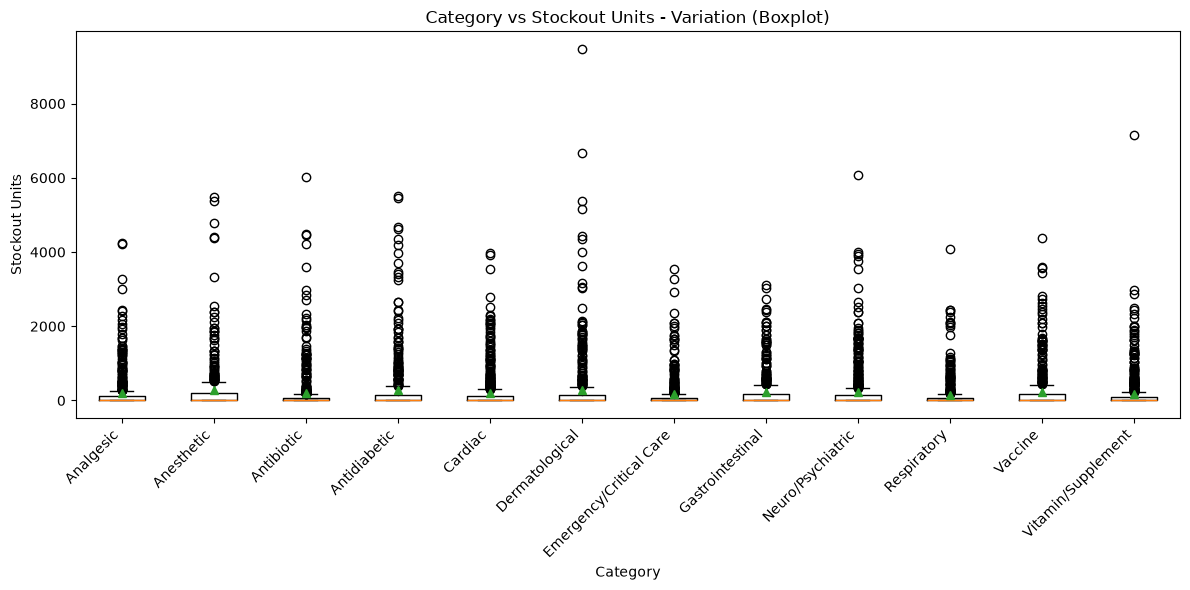

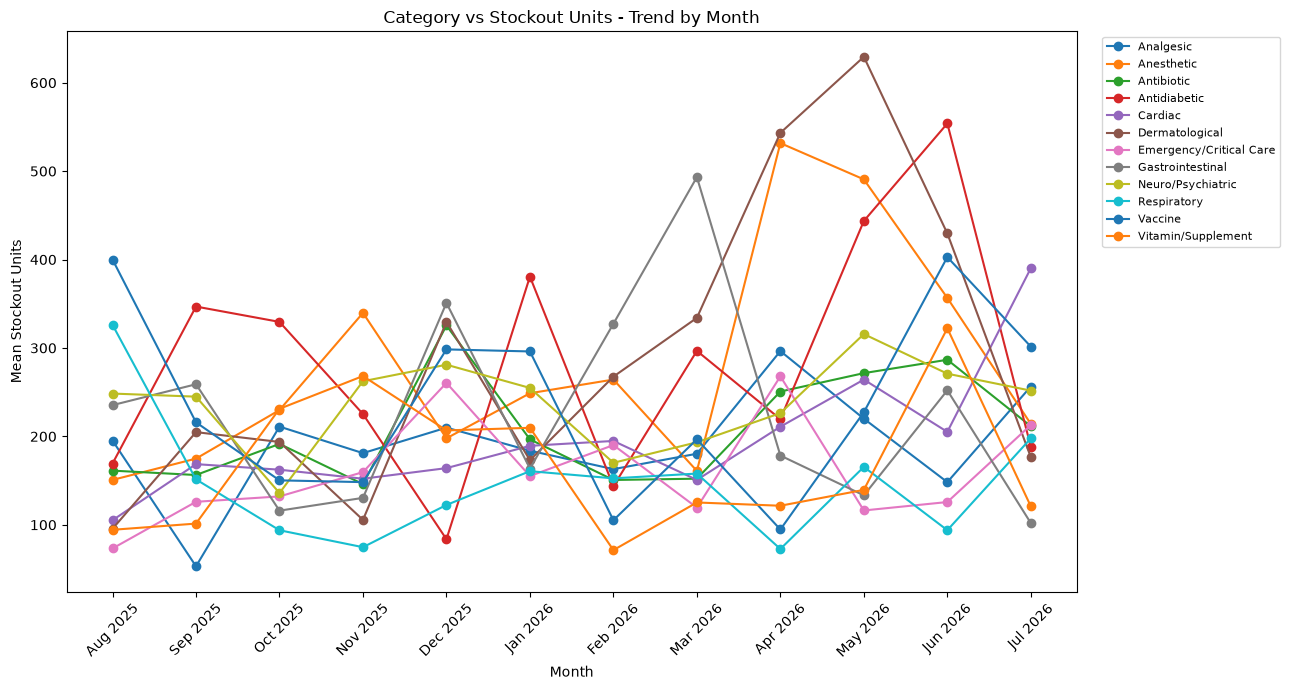

In [38]:

merged['Month'] = pd.to_datetime(merged['Month'], format='%Y-%m')

cat_order = merged.groupby('Category')['Stockout_Units'].median().sort_values(ascending=False).index
data_by_cat = [merged[merged['Category']==c]['Stockout_Units'].values for c in cat_order]
fig, ax = plt.subplots(figsize=(12,6))
ax.boxplot(data_by_cat, tick_labels=cat_order, showmeans=True)
ax.set_title('Category vs Stockout Units - Variation (Boxplot)')
ax.set_xlabel('Category'); ax.set_ylabel('Stockout Units')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

pivot = merged.pivot_table(index='Month', columns='Category', values='Stockout_Units', aggfunc='mean').sort_index()
month_labels = pivot.index.strftime('%b %Y')
plt.figure(figsize=(13,7))
for cat in pivot.columns:
    plt.plot(month_labels, pivot[cat], marker='o', label=cat)
plt.title('Category vs Stockout Units - Trend by Month')
plt.xlabel('Month'); plt.ylabel('Mean Stockout Units')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

category v/s lead time

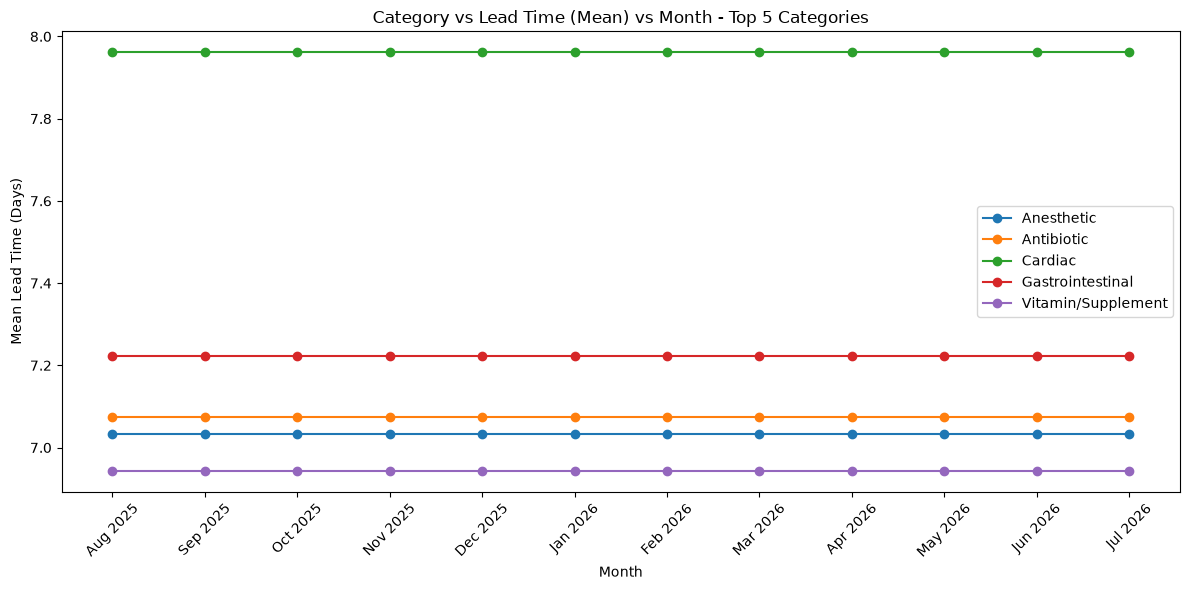

In [39]:

top5_cats = merged.groupby('Category')['Lead_Time_Days'].mean().sort_values(ascending=False).head(5).index

pivot = merged[merged['Category'].isin(top5_cats)].pivot_table(
    index='Month', columns='Category', values='Lead_Time_Days', aggfunc='mean'
)
pivot = pivot.sort_index()
month_labels = pivot.index.strftime('%b %Y')

plt.figure(figsize=(12,6))
for cat in pivot.columns:
    plt.plot(month_labels, pivot[cat], marker='o', label=cat)
plt.title('Category vs Lead Time (Mean) vs Month - Top 5 Categories')
plt.xlabel('Month'); plt.ylabel('Mean Lead Time (Days)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

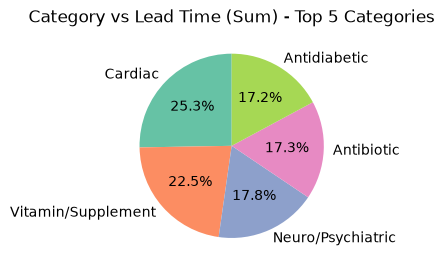

In [41]:


cat_sum = merged.groupby('Category')['Lead_Time_Days'].sum().sort_values(ascending=False)
top5_sum = cat_sum.head(5)

plt.figure(figsize=(4,4))
plt.pie(top5_sum, labels=top5_sum.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
plt.title('Category vs Lead Time (Sum) - Top 5 Categories')
plt.tight_layout()
plt.show()

category v/s holding cost 

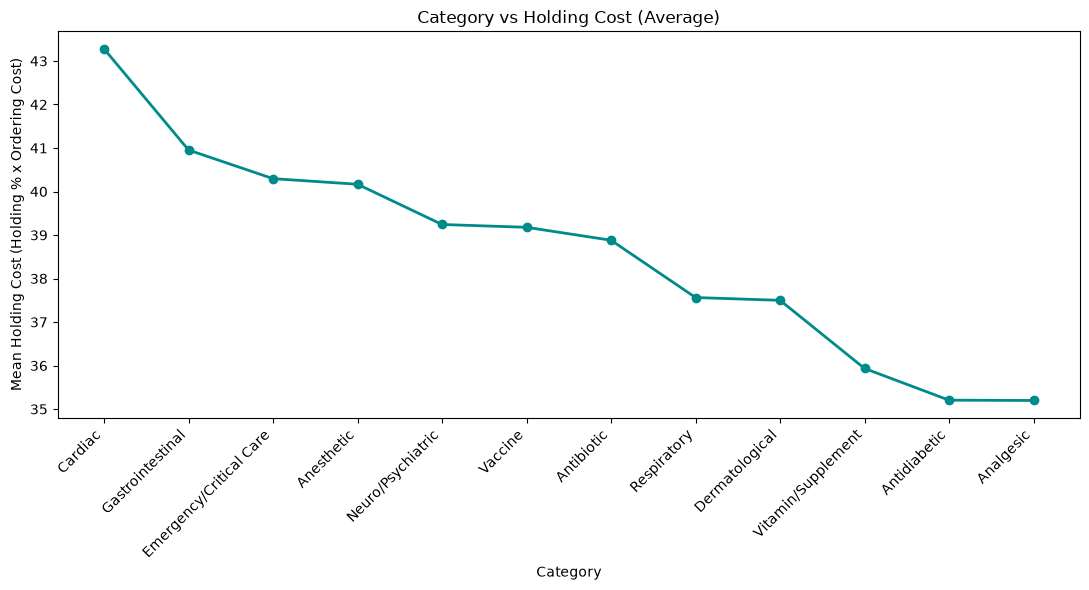

In [43]:

merged['Holding_Cost_Value'] = merged['Holding_Cost_Percent'] * merged['Ordering_Cost_INR']

cat_avg = merged.groupby('Category')['Holding_Cost_Value'].mean().sort_values(ascending=False)

plt.figure(figsize=(11,6))
plt.plot(cat_avg.index, cat_avg.values, marker='o', color='darkcyan', linewidth=2)
plt.title('Category vs Holding Cost (Average)')
plt.xlabel('Category'); plt.ylabel('Mean Holding Cost (Holding % x Ordering Cost)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

category v/s ordering cost

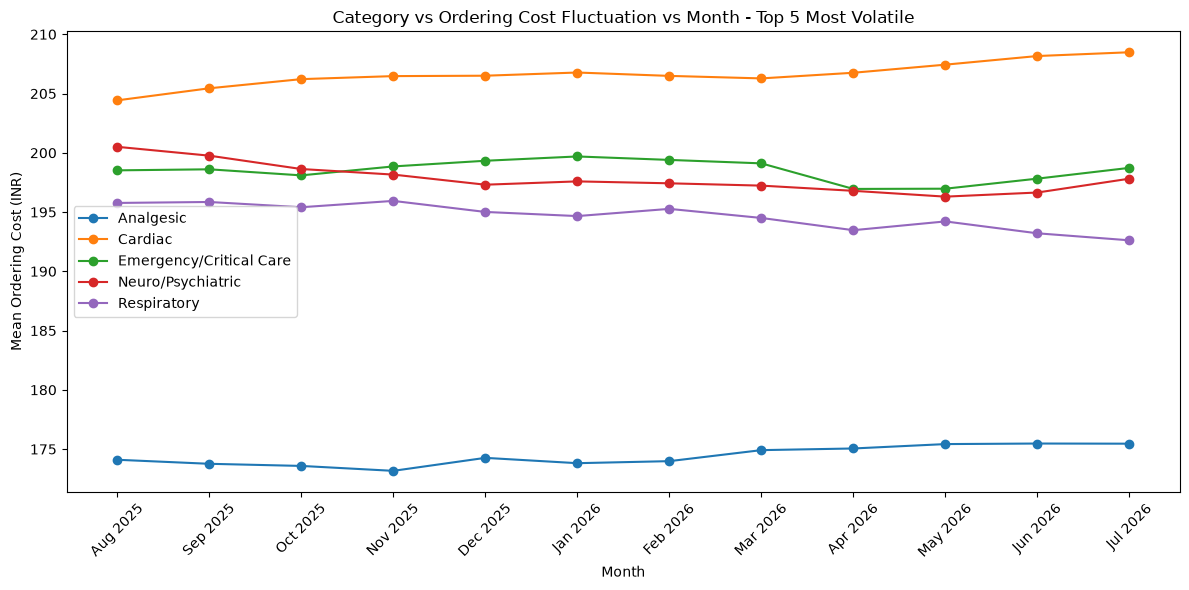

In [44]:

cat_month_avg = merged.groupby(['Category','Month'])['Ordering_Cost_INR'].mean().reset_index()
fluctuation = cat_month_avg.groupby('Category')['Ordering_Cost_INR'].std().sort_values(ascending=False)
top5_cats = fluctuation.head(5).index

pivot = merged[merged['Category'].isin(top5_cats)].pivot_table(
    index='Month', columns='Category', values='Ordering_Cost_INR', aggfunc='mean'
)
pivot = pivot.sort_index()
month_labels = pivot.index.strftime('%b %Y')

plt.figure(figsize=(12,6))
for cat in pivot.columns:
    plt.plot(month_labels, pivot[cat], marker='o', label=cat)
plt.title('Category vs Ordering Cost Fluctuation vs Month - Top 5 Most Volatile')
plt.xlabel('Month'); plt.ylabel('Mean Ordering Cost (INR)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

category v/s shelf life


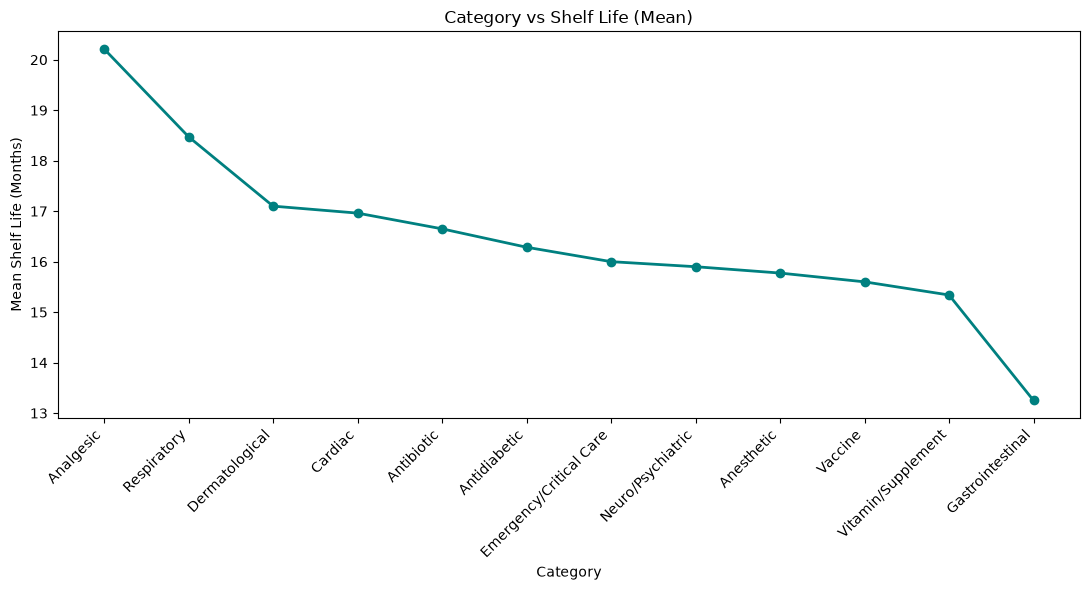

In [45]:


cat_mean = medicine_info.groupby('Category')['Shelf_Life_Months'].mean().sort_values(ascending=False)

plt.figure(figsize=(11,6))
plt.plot(cat_mean.index, cat_mean.values, marker='o', color='teal', linewidth=2)
plt.title('Category vs Shelf Life (Mean)')
plt.xlabel('Category'); plt.ylabel('Mean Shelf Life (Months)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()